# Разработка модели многоклассовой классификации для предсказания возраста интернет-пользователей по "цифровому следу"

- Автор: Татьяна Дмитриева
- Дата: 10.05.2026

**Описание исследования**: В рамках данного проекта исследуется процесс определения возрастной категории пользователей на основе их активности в сети для IT-компании "Йети". Работа охватывает полный цикл разработки ML-решения: от объединения данных из различных источников (логи посещений, активность в рекламе, типы устройств) и исследовательского анализа до построения автоматизированных пайплайнов предобработки и обучения моделей. Приорететными задачами в рамках проекта является генерация признаков на основе поведенческих признаков и минимизации рисков ошибочного показа взрослой рекламы несовершеннолетним. 

**Цель исследования**: Построить модель машинного обучения, которая максимально точно классифицирует анонимных пользователей по пяти возрастным категориям, обеспечивая значение `F1-меры` модели не меньше 0,75 и на кросс-валидации по обучающей выборке, и на тестовой выборке.

**Задачи исследования**:  
- изучить структуру предоставленных датасетов (`users`, `visits`, `ads_activity`, `surf_depth`, `primary_device`, `cloud_usage`), провести исследовательский анализ (`EDA`) и выявить закономерности в поведении разных возрастных групп;  
- разработать функцию для объединения данных в единое признаковое пространство и обработать пропуски, дубликаты и выбросы;  
- провести конструирование признаков, на основе исходных данных, включая расчет долей интернет-активности по категориям сайтов и времени суток;  
- подготовить пайплайны предобработки данных, включая кодирование категориальных признаков и масштабирование числовых данных без утечек из тестовой выборки;  
- выполнить отбор наиболее значимых признаков для борьбы с мультиколлинеарностью и снижения размерности;  
- построить и обучить базовые модели (`DummyClassifier`, `LogisticRegression`, `SVC`) и провести их сравнительную оценку;  
- подобрать оптимальные гиперпараметры с использованием кросс-валидации и стратификации по целевому признаку;  
- проанализировать результаты, сформировать итоговый отчет и сохранить финальный пайплайн в формате `joblib` для промышленной эксплуатации.  
_____
**Исходные данные**:  

Данные получены из разных источников и поэтому представлены в нескольких CSV-файлах.  

**Таблица `users`**, представленная файлом `ds_s13_users.csv`, содержит информацию о возрастной категории пользователя:  
-	`user_id` — уникальный идентификатор пользователя;  
-	`age_category` — возрастная категория пользователя, этот показатель модель должна научиться предсказывать. Содержит следующие категории:  
•	`0`: младше 18;  
•	`1`: 18-25 лет;  
•	`2`: 26-40 лет;  
•	`3`: 41-55 лет;  
•	`4`: 56+ лет.  

**Таблица `visits`**, представленная логом посещений сайтов `ds_s13_visits.csv`, содержит информацию об активности интернет-пользователей:  
-	`date` — дата посещения сайта;  
-	`daytime` — анонимизированное время посещения сайта. Категории: `утро`, `день`, `вечер`, `ночь`;   
-	`session_id` — уникальный идентификатор сессии. Сессия — это последовательность действий пользователя на сайте, которая начинается при первом взаимодействии с ресурсом и завершается по правилам тайм-аута или смены условий;  
-	`user_id` — уникальный идентификатор пользователя;  
-	`website_category` — анонимизированная категория сайта. В лог включены несколько десятков категорий, которые позволяют эффективно сегментировать аудиторию. Это позволяет сократить пространство признаков модели без потери её качества.  

**Таблица `ads_activity`**, представленная файлом `ads_activity.csv`, содержит информацию об активности взаимодействия пользователя с рекламными объявлениями:  
-	`user_id` — уникальный идентификатор пользователя;  
-	`ads_activity` — характеристика CTR, выраженная одним из значений: `очень редко`, `редко`, `умеренно`, `часто`, `очень часто`.  

**Таблица `surf_depth`**, представленная файлом `surf_depth.csv`, содержит два признака:  
-	`user_id` — уникальный идентификатор пользователя;  
-	`surf_depth` — категориальная переменная, характеризующая глубину перехода пользователя по сайтам во время одной сессии. Содержит категории `поверхностно`, `средне`, `глубоко`.  

**Таблица `primary_device`**, представленная файлом `primary_device.csv`, содержит два признака:  
-	`user_id` — уникальный идентификатор пользователя;  
-	`primary_device` — информация о типе основного устройства пользователя для выхода в Интернет.  

**Таблица `cloud_usage`**, представленная файлом `cloud_usage.csv`, содержит информацию об использовании облачных технологий:  
-	`user_id` — уникальный идентификатор пользователя;  
-	`cloud_usage` — `True` означает, что пользователь обращается к облачным ресурсам прямо или через посещаемые сайты.  

_______

**Поставновка задачи машинного обучения**

***Тип задачи***
Проект реализуется в рамках задачи многоклассовой классификации с учителем (`Supervised Learning`). На основе данных о "цифровом следе" модель должна предсказывать вероятность принадлежности анонимного пользователя к одной из пяти возрастных групп.  

***Целевой признак (Target)***: `age_category` (категориальная величина)  
•	`0`: младше 18;  
•	`1`: 18-25 лет;  
•	`2`: 26-40 лет;  
•	`3`: 41-55 лет;  
•	`4`: 56+ лет.  

***Проблема***  
Маркетинговая команда "Йети" планирует запуск двух масштабных рекламных кампаний, для которых критически важна точность попадания в целевую аудиторию. Отсутствие автоматизированной сегментации по возрасту несет в себе двойную угрозу:  
- Экономическую: нецелевые показы объявлений снижают эффективность (`CTR`) и ведут к перерасходу бюджета;  
- Репутационную и регуляторную: существует риск демонстрации контента категории "для взрослых" несовершеннолетним пользователям, что требует превентивных мер контроля.  

***Цель бизнеса***  
Обеспечить фундамент для реализации маркетинговой стратегии через высокоточное профилирование аудитории. Это позволит:
- направлять рекламные сообщения на корректные возрастные сегменты;  
- минимизировать риск попадания взрослого контента в поле зрения несовершеннолетних, тем самым предвосхищая возможные этические и юридические инциденты.   

***Логика ML***  
Алгоритм анализирует совокупность признаков (интенсивность и глубину серфинга, типы используемых устройств, доли времени активности по категориям сайтов и суточным ритмам) и соотносит профиль пользователя с историческими паттернами поведения каждой возрастной группы. Результатом работы сквозного автоматизированного пайплайна является отнесение профиля пользователя к тому классу, который максимизирует целевую функцию многоклассового линейного классификатора. 

***Обоснование выбора метрик***  
Для оценки модели используются одна ключевая и несколько вспомогательных метрик:  
- `F1-macro` (основная) наиболее адекватно оценивает качество модели в условиях многоклассовой классификации. Она фокусируется на балансе между точностью и полнотой, позволяя равноценно учитывать все возрастные группы (даже редкие), что критически важно для корректного охвата всей целевой аудитории;  
- `Precision` и `Recall` используются для оценки качества предсказаний в разрезе каждого класса. Это помогает убедиться, что модель не только находит представителей нужной группы, но и делает это с минимальным количеством ошибок (например, не допуская попадания несовершеннолетних в сегменты "18+");  
- `Confusion Matrix` (матрица ошибок) применяется для детального анализа того, какие возрастные категории модель путает чаще всего, что позволяет точнее настраивать маркетинговые фильтры.  

***Ожидаемый результат***  
Обученная модель, которая выдает надежный прогноз возрастной категории пользователя. Результатом работы должен стать пайплайн, обеспечивающий значение `F1-macro` не ниже 0,75 на кросс-валидации и тестовой выборке. Это позволит бизнесу автоматизировать сегментацию аудитории, повысить `CTR` объявлений и исключить репутационные риски.  
_____
# Структура проекта

[1. Подготовка среды и библиотек](#1-bullet)   
[2. Исследовательский анализ данных](#2-bullet)  
[3. Предобработка данных](#3-bullet)  
[4. Обучение и оценка базовой модели](#4-bullet)  
[5. Создание и отбор признаков](#5-bullet)  
[6. Подбор гиперпараметров моделей](#6-bullet)  
[7. Финальное тестирование и оценка качества модели](#7-bullet)  
[8. Подготовка артефактов модели для внедрения](#8-bullet)  
[9. Выводы о результатах работы](#9-bullet)  

______

<a id="1-bullet"></a>
## Подготовка среды и библиотек

Для начала подготовим рабочее окружение: установим и импортируем необходимые библиотеки для обработки данных, визуализации и машинного обучения. Группировку импортов выполняем согласно стандарту `PEP8` (стандартные библиотеки, сторонние, затем инструменты `ML`). Для корректной работы проекта и воспроизводимости результатов версии используемых библиотек зафиксированы в файле `requirements.txt`. Ссылка на файл дана в конце проекта.

In [1]:
# Установка сторонних библиотек
!pip install scikit-learn==1.3.2 phik -q

# Импорты из стандартной библиотеки
from functools import partial
import os
import warnings

# Импорты сторонних библиотек
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from phik import phik_matrix

# Инструменты машинного обучения
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import (
    SelectKBest, 
    mutual_info_classif
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import (
    GridSearchCV,
    cross_validate,
    StratifiedKFold,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC

Инструменты `Pipeline` и `ColumnTransformer` будут использоваться при создании автоматизированных пайплайнов предобработки. Они позволят объединить масштабирование чисел (`StandardScaler`) и кодирование категорий (`OneHotEncoder`) в единый процесс без утечек данных. Для всех категориальных признаков, включая высокоразмерную тематику сайтов, будет применен метод прямого кодирования (`OneHotEncoder`). Это позволит линейным моделям (`LogisticRegression` и `LinearSVC`) эффективно и независимо оценить вклад каждой конкретной категории в итоговое предсказание возраста.  

Инструмент `phik_matrix` идеально подойдет для комплексного анализа взаимосвязей между признаками любых типов (включая нелинейные зависимости категорий с целевой переменной) на этапе `EDA`. Инструменты автоматического отбора признаков `SelectKBest` и `RFE` понадобятся нам далее для борьбы с мультиколлинеарностью и снижения избыточной размерности признакового пространства после `OHE-кодирования`. Класс `CalibratedClassifierCV` поможет преобразовать расстояния до разделяющей гиперплоскости базового `LinearSVC` в честные вероятности принадлежности пользователя к конкретному классу, так как из коробки этот алгоритм вероятностей не выдает.

Стратифицированное разбиение `StratifiedKFold` закладывается как обязательный инструмент кросс-валидации для защиты от возможного дисбаланса классов, который часто встречается в демографических задачах. Также зададим единую константу `RANDOM_STATE` для обеспечения воспроизводимости всех дальнейших расчетов, константу `TEST_SIZE = 0,25` для выделения тестовой выборки в диапазоне от 20% до 30% и настроим параметры отображения таблиц.

In [2]:
# Константы для воспроизводимости и разделения данных
RANDOM_STATE = 42 
TEST_SIZE = 0.25  # Доля тестовой выборки

# Настройки отображения
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
os.environ["PYTHONWARNINGS"] = "ignore"
pd.set_option('display.max_columns', None)

# Настройки визуализации
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 10, 'figure.figsize': (10, 6)})

Для загрузки данных подготовим словарь, сопоставляющий названия таблиц с именами их файлов. Загрузка реализована через конструкцию `try-except`: система сначала попытается найти файлы по пути `/datasets/` (при проверке проекта на учебной платформе), а в случае их отсутствия - загрузит данные из удаленного хранилища (`S3`) по ссылкам. Такой подход обеспечит универсальность кода и позволит беспрепятственно запускать проект как в локальном окружении, так и на сервере.

In [3]:
# Словарь соответствия имен таблиц и файлов
data_files = {
    'users': 'ds_s13_users.csv',
    'visits': 'ds_s13_visits.csv',
    'ads_activity': 'ads_activity.csv',
    'surf_depth': 'surf_depth.csv',
    'primary_device': 'primary_device.csv',
    'cloud_usage': 'cloud_usage.csv'
}

# Словарь для хранения загруженных датафреймов
datasets = {}

for table_name, file_name in data_files.items():
    # Формируем оба пути: серверный (локальный для учебной платформы) и внешний (S3)
    path_practicum = f'/datasets/{file_name}'
    path_s3 = f'https://code.s3.yandex.net/datasets/{file_name}'
    
    try:
        # Пробуем путь учебной платформы
        datasets[table_name] = pd.read_csv(path_practicum)
        print(f'Таблица {table_name}: загружена из папки /datasets/ Практикума')
    except Exception:
        try:
            # Пробуем внешнюю ссылку (для работы на компьютере)
            datasets[table_name] = pd.read_csv(path_s3)
            display(f'Таблица {table_name}: загружена по внешней ссылке')
        except Exception as e:
            display(f'Ошибка при загрузке таблицы {table_name}: {e}')

# Присваиваем датафреймы переменным
df_users = datasets.get('users')
df_visits = datasets.get('visits')
df_ads_activity = datasets.get('ads_activity')
df_surf_depth = datasets.get('surf_depth')
df_primary_device = datasets.get('primary_device')
df_cloud_usage = datasets.get('cloud_usage')

Таблица users: загружена из папки /datasets/ Практикума
Таблица visits: загружена из папки /datasets/ Практикума
Таблица ads_activity: загружена из папки /datasets/ Практикума
Таблица surf_depth: загружена из папки /datasets/ Практикума
Таблица primary_device: загружена из папки /datasets/ Практикума
Таблица cloud_usage: загружена из папки /datasets/ Практикума


После загрузки необходимо убедиться в корректности структуры данных. Проверим первые строки и общую информацию по всем таблицам, чтобы оценить объемы и типы данных, а также выявить наличие явных пропусков.

In [4]:
# Создаем список пар (название, датафрейм) для удобного вывода в цикле
all_datasets = [
    ('Пользователи', df_users),
    ('Визиты', df_visits),
    ('Активность рекламы', df_ads_activity),
    ('Глубина серфинга', df_surf_depth),
    ('Основное устройство', df_primary_device),
    ('Использование облака', df_cloud_usage)
]

for title, df in all_datasets:
    display(f"======   {title}  =======")
    if df is not None:
        # Выводим первые строки для визуальной проверки
        display(df.head())
        # Выводим техническую информацию о типах и пропусках
        df.info()
    else:
        display(f"Ошибка: Данные для таблицы '{title}' не загружены.")

'======   Пользователи  ======='

,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5913 non-null   object
 1   age_category  5913 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 92.5+ KB


'======   Визиты  ======='

,date,daytime,session_id,user_id,website_category
0,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 17
1,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 19
2,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 18
3,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 20
4,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 05


...

,user_id,primary_device
0,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
1,9204-9558455be649d4e77945-b5e25d62,ПК
2,5eea-22babd6a9474b43b9d0b-a39a4cf2,ноутбук
3,c142-0296948e8d08e417de10-2da9523c,смартфон
4,abec-bb4092da51eb2233a928-e44ba074,ПК


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   user_id         5669 non-null   object
 1   primary_device  5669 non-null   object
dtypes: object(2)
memory usage: 88.7+ KB


'======   Использование облака  ======='

,user_id,cloud_usage
0,a1e4-91c8a52eb855595e653f-298ce305,False
1,db9a-7b8e9e94448b7fcb19b6-4edca15f,False
2,0d55-9ad768879e9b08ca7ff9-843f76c7,True
3,4baa-43285d10a6d3cc969f2a-b21881d1,False
4,b8cd-cbb2411db005115ca64d-32700c62,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      5680 non-null   object
 1   cloud_usage  5680 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 50.0+ KB


Как можно заметить, все 6 таблиц успешно загружены. Механизм автоматического переключения путей (`try-except`) отработал корректно, обеспечив доступ к содержащимся в них данным. По результатам первичного анализа датасетов можно сделать следующие выводы:

- Основная таблица `df_users` содержит 5913 записей, что соответствует количеству уникальных пользователей. Таблица `df_visits` является самой объемной (более 1 млн строк), что потребует оптимизации при агрегации признаков. Вспомогательные таблицы (`ads_activity`, `surf_depth` и др.) имеют чуть меньшее количество записей (от 5669 до 5826). Это означает, что для части пользователей данные о "цифровом следе" отсутствуют, что потребует обработки пропусков при объединении. 
- Названия столбцов и их содержание полностью соответствуют описанию проекта. Целевой признак `age_category` представлен в целочисленном формате, классы размечены. 
- Столбец `date` в таблице `df_visits` распознан как `object`. Его необходимо привести к формату `datetime` для извлечения временных признаков. Признаки в таблицах активности, глубины серфинга и типа устройства являются категориальными и требуют кодирования (категориального преобразования) на этапе подготовки модели. Идентификаторы `user_id` представлены в виде длинных строковых хешей, что удобно для объединения таблиц методом `merge`. 

Дальнейшая работа будет сосредоточена на объединении разрозненных таблиц в единый профиль пользователя. Основной акцент в исследовательском анализе будет сделан на изучении дисбаланса целевого класса и анализе цифровых привычек разных возрастных групп (предпочтительное время суток, категории сайтов и тип устройств). Это позволит отобрать наиболее значимые признаки и отсеять избыточные, чтобы избежать переобучения модели.

<a id="2-bullet"></a>
## Исследовательский анализ данных

На данном этапе будет проведено детальное изучение структуры и качества данных. Исследовательский анализ позволит выявить скрытые закономерности, обнаружить аномалии и оценить взаимосвязи между признаками. 

**2.1. Технический аудит качества исходных данных**

Начнем с технической проверки на дубликаты. В этом проекте у нас есть таблицы двух типов: те, где один пользователь должен встречаться строго один раз (например, данные об устройстве), и логи (визиты), где повторы допустимы, но полные дубликаты строк всё равно могут быть технической ошибкой.

Поэтому прежде чем приступать к анализу, необходимо убедиться, что данные не содержат полных дубликатов строк. Такие повторы могут возникнуть при технических сбоях выгрузки и способны исказить итоговую статистику и метрики модели. Проверим каждую из шести таблиц.

In [5]:
# Проверяем количество полных строк-дубликатов по всем таблицам в цикле
for name, df in all_datasets:
    display(f"Таблица '{name}': дубликатов — {df.duplicated().sum()}")

"Таблица 'Пользователи': дубликатов — 87"

"Таблица 'Визиты': дубликатов — 15750"

"Таблица 'Активность рекламы': дубликатов — 233"

"Таблица 'Глубина серфинга': дубликатов — 0"

"Таблица 'Основное устройство': дубликатов — 0"

"Таблица 'Использование облака': дубликатов — 0"

Результат проверки показал, что данные нуждаются в очистке. В трех таблицах из шести обнаружены полные дубликаты. Наибольшее их количество сосредоточено в таблице `df_visits` (15750 строк), также повторы присутствуют в данных о пользователях `df_users` (87 строк) и их рекламной активности `df_ads_activity`(233 строки). Появление полных дубликатов, скорее всего, связано с техническими особенностями логирования или сбоями при выгрузке. Поскольку такие строки не несут новой информации и могут привести к смещению статистических показателей, их необходимо удалить.

Для корректного проведения дальнейшего анализа и обучения модели удалим полные дубликаты в тех таблицах, где они были обнаружены: `df_users`, `df_visits` и `df_ads_activity`. Для остальных таблиц данная процедура не требуется. При удалении используем метод `reset_index(drop=True)`, чтобы восстановить непрерывную нумерацию строк.

In [6]:
# Удаляем дубликаты в 3 таблицах
df_users = df_users.drop_duplicates().reset_index(drop=True)
df_visits = df_visits.drop_duplicates().reset_index(drop=True)
df_ads_activity = df_ads_activity.drop_duplicates().reset_index(drop=True)

# Обновим список all_datasets, чтобы в нем хранились актуальные (чистые) данные
all_datasets = [
    ('Пользователи', df_users),
    ('Визиты', df_visits),
    ('Активность рекламы', df_ads_activity),
    ('Глубина серфинга', df_surf_depth),
    ('Основное устройство', df_primary_device),
    ('Использование облака', df_cloud_usage)
]

display("Дубликаты успешно удалены.")

'Дубликаты успешно удалены.'

Теперь в датафреймах остались только уникальные записи. Это гарантирует, что при дальнейшем агрегировании данных (например, подсчете количества визитов на одного пользователя) не будет завышенных показателей из-за технических повторов.

На этапе ппервичного анализа данных было замечено, что некоторые признаки (например, дата) представлены в формате `object`. Чтобы в дальнейшем извлекать из них полезную информацию (например, день недели), необходимо привести их к соответствующим типам. Посмотрим на текущие типы данных во всех таблицах.

In [7]:
# Выводим типы данных для каждой таблицы через .dtypes
for name, df in all_datasets:
    display(f"Типы данных в таблице '{name}'")
    display(df.dtypes)
    display()

"Типы данных в таблице 'Пользователи'"

user_id         object
age_category     int64
dtype: object

"Типы данных в таблице 'Визиты'"

date                object
daytime             object
session_id          object
user_id             object
website_category    object
dtype: object

"Типы данных в таблице 'Активность рекламы'"

...

user_id       object
surf_depth    object
dtype: object

"Типы данных в таблице 'Основное устройство'"

user_id           object
primary_device    object
dtype: object

"Типы данных в таблице 'Использование облака'"

user_id        object
cloud_usage      bool
dtype: object

Проверка типов подтвердила, что практически все признаки, включая категориальные, распознаны корректно. Однако столбец `date` в таблице `df_visits` представлен строковым типом. Для того чтобы изучить распределение визитов по дням или месяцам, а в дальнейшем - создать признаки на основе времени, необходимо перевести этот столбец в формат `datetime64`.

Для корректной работы с временными рядами преобразуем столбец `date` в таблице `df_visits` из строкового типа в формат даты.

In [8]:
# Преобразование столбца date в формат datetime
df_visits['date'] = pd.to_datetime(df_visits['date'])

# Обновим данные в общем списке, чтобы изменения сохранились везде
for i, (name, df) in enumerate(all_datasets):
    if name == 'Визиты':
        all_datasets[i] = (name, df_visits)

# Проверка результата преобразования
f"Новый тип столбца 'date' в Визитах: {df_visits['date'].dtype}"

"Новый тип столбца 'date' в Визитах: datetime64[ns]"

Проверим текстовые категории на наличие неявных дубликатов (например, различия в регистре или опечатках). Также оценим количество уникальных значений: если их немного, то сможем просмотреть весь список и убедиться в корректности данных.

In [9]:
# Определим список столбцов для проверки в каждой таблице
categorical_cols = {
    'Визиты': ['daytime', 'website_category'],
    'Активность рекламы': ['ads_activity'],
    'Глубина серфинга': ['surf_depth'],
    'Основное устройство': ['primary_device']
}

# В цикле выведем уникальные значения для каждого признака
for table_name, columns in categorical_cols.items():
    # Находим датафрейм в all_datasets по имени
    df = next(item[1] for item in all_datasets if item[0] == table_name)
    
    display(f"--- Таблица '{table_name}' ---")
    for col in columns:
        unique_values = df[col].unique()
        print(f"Признак '{col}': {len(unique_values)} уникальных значений")
        print(f"Значения: {unique_values}")

"--- Таблица 'Визиты' ---"

Признак 'daytime': 4 уникальных значений
Значения: ['вечер' 'день' 'ночь' 'утро']
Признак 'website_category': 20 уникальных значений
Значения: ['Category 17' 'Category 19' 'Category 18' 'Category 20' 'Category 05'
 'Category 12' 'Category 03' 'Category 15' 'Category 10' 'Category 06'
 'Category 04' 'Category 09' 'Category 01' 'Category 11' 'Category 07'
 'Category 14' 'Category 08' 'Category 13' 'Category 02' 'Category 16']


"--- Таблица 'Активность рекламы' ---"

Признак 'ads_activity': 5 уникальных значений
Значения: ['очень часто' 'редко' 'очень редко' 'умеренно' 'часто']


"--- Таблица 'Глубина серфинга' ---"

Признак 'surf_depth': 3 уникальных значений
Значения: ['поверхностно' 'глубоко' 'средне']


"--- Таблица 'Основное устройство' ---"

Признак 'primary_device': 4 уникальных значений
Значения: ['смартфон' 'ПК' 'ноутбук' 'планшет']


Анализ уникальных значений показал, что категориальные признаки в проекте хорошо структурированы. Неявные дубликаты, опечатки или нарушения регистра не обнаружены. Все текстовые значения унифицированы, что позволяет использовать их в дальнейшем анализе без дополнительной очистки.

На этапе первичного ознакомления с данными (метод `info()`) было установлено, что все шесть исходных таблиц не содержат пропущенных значений. Проверим это утверждение, чтобы убедиться в полноте предоставленной информации по каждому сервису.

In [10]:
# Проверка наличия пропусков во всех таблицах
for name, df in all_datasets:
    print(f"Таблица '{name}': пропусков — {df.isna().sum().sum()}")

Таблица 'Пользователи': пропусков — 0
Таблица 'Визиты': пропусков — 0
Таблица 'Активность рекламы': пропусков — 0
Таблица 'Глубина серфинга': пропусков — 0
Таблица 'Основное устройство': пропусков — 0
Таблица 'Использование облака': пропусков — 0


Пропуски в датасетах отсутствуют, что говорит о высоком качестве выгрузки. Однако стоит учитывать, что вспомогательные таблицы (активность, облако, устройство) имеют разное количество записей. Это означает, что при будущем объединении данных в единый профиль пользователя возникнут пропуски для тех клиентов, которые не пользуются конкретными сервисами. Эти пропуски потребуют обработки перед этапом моделирования.

В ходе первичной подготовки данных была проведена полная ревизия шести исходных таблиц. Устранены явные дубликаты (наибольшее количество которых - более 15 тысяч - содержалось в логах визитов), скорректированы типы временных меток. Подтверждено отсутствие скрытых символов в текстовых категориях и отсутствие в исходных таблицах пропущенных значений. Это свидетельствует о высоком качестве предоставленной выгрузки. Таким образом, данные приведены к единому стандарту, проверены на целостность и полностью готовы к содержательному исследовательскому анализу.

**2.2. Анализ целевой переменной**

Центральным объектом исследования является возрастная категория пользователей. На данном этапе рассмотрим, как распределены данные по пяти целевым группам (от `"0"` до `"4"`). Важно определить, наблюдается ли в выборке существенный дисбаланс классов. Наличие сильного перекоса (например, если одна из возрастных групп представлена значительно меньшим количеством анкет) может потребовать применения специальных техник при обучении модели, таких как взвешивание классов или использование стратифицированной выборки.  

С помощью столбчатой диаграммы визуализируем количество представителей каждой из пяти групп:

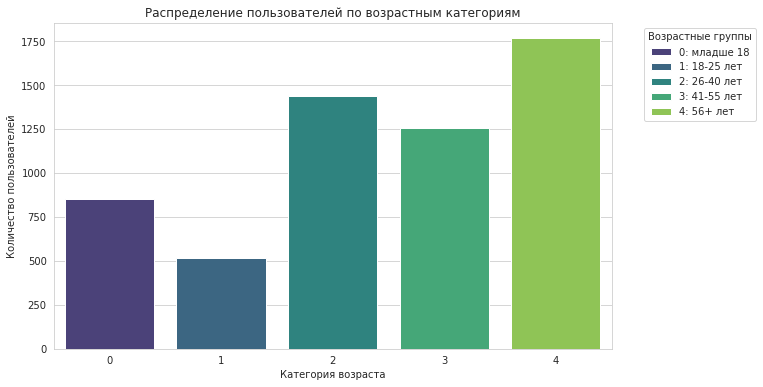

'Доля каждой категории в общем объеме данных:'

,age_category
0,14.64%
1,8.82%
2,24.70%
3,21.52%
4,30.31%


In [11]:
# Создаем словарь для расшифровки категорий
age_labels = {
    0: '0: младше 18',
    1: '1: 18-25 лет',
    2: '2: 26-40 лет',
    3: '3: 41-55 лет',
    4: '4: 56+ лет'
}

# Добавляем временный столбец с названиями классов
df_users['age_group_name'] = df_users['age_category'].map(age_labels)

plt.figure(figsize=(10, 6))

# Строим график
ax = sns.countplot(
    data=df_users.sort_values('age_category'), 
    x='age_category', 
    hue='age_group_name', 
    palette='viridis',
    dodge=False
)

plt.title('Распределение пользователей по возрастным категориям')
plt.xlabel('Категория возраста')
plt.ylabel('Количество пользователей')

# Настраиваем легенду
plt.legend(title='Возрастные группы', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

# Удаляем временный столбец
df_users.drop('age_group_name', axis=1, inplace=True)

# Вывод точных значений
display("Доля каждой категории в общем объеме данных:")
display(df_users['age_category'].value_counts(normalize=True).sort_index().to_frame().style.format('{:.2%}'))

По результатам анализа графика и таблицы можно сделать вывод о неравномерном распределении классов:

- Данные имеют явный дисбаланс классов. Самой многочисленной является категория `"56+ лет"` (30,31%), в то время как категория `"18-25 лет"` представлена меньше всего - её доля составляет лишь 8,82%. Разрыв между самым крупным и самым малочисленным классом получается более чем в три раза.
- Целевая группа с несовершеннолетними (`"младше 18"`), защита которой выделена в приоритет, составляет 14,64% выборки. Этого объема данных достаточно для обучения, но важно следить, чтобы модель не начала ошибочно относить их к более массовым "взрослым" категориям.

При разделении данных на обучающую и тестовую выборки обязательно использование стратификации (`stratify=y`), чтобы сохранить текущие пропорции в обоих наборах. Поскольку классы не равны, использование метрики `Accuracy` будет некорректным. Это подтверждает правильность выбора `F1-macro` в качестве основной метрики, так как она будет учитывать качество предсказания для каждого класса независимо от его размера.

**2.3. Анализ признаков**

Анализ признаков начнем с изучения используемых устройств, так как тип гаджета - один из наиболее выразительных элементов "цифрового следа", который часто коррелирует с возрастом и образом жизни человека. Информация о первичном устройстве пользователя позволяет сегментировать аудиторию по технологическим предпочтениям. На данном этапе изучим, какие типы устройств (смартфоны, планшеты, ПК) преобладают в выборке. Это поможет в дальнейшем проверить гипотезу о том, склонны ли определенные возрастные группы к использованию конкретных типов гаджетов.

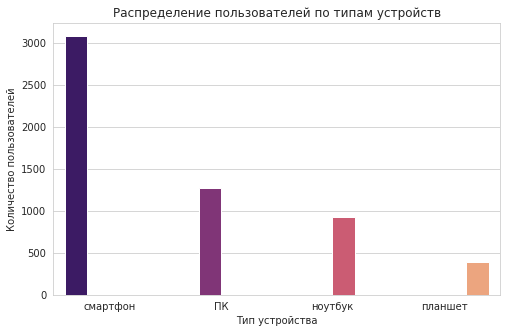

'Доля типов устройств в выборке:'

,primary_device
смартфон,54.38%
ПК,22.49%
ноутбук,16.28%
планшет,6.84%


In [12]:
# Настройка размера графика
plt.figure(figsize=(8, 5))

# Строим график
sns.countplot(
    data=df_primary_device, 
    x='primary_device', 
    hue='primary_device',
    palette='magma'
)

# Настройка подписей
plt.title('Распределение пользователей по типам устройств')
plt.xlabel('Тип устройства')
plt.ylabel('Количество пользователей')
plt.legend([], frameon=False) 

# Вывод графика
plt.show()

# Вывод процентного соотношения для анализа
display("Доля типов устройств в выборке:")
display(df_primary_device['primary_device'].value_counts(normalize=True).to_frame().style.format('{:.2%}'))

По результатам анализа графика и таблицы можно сделать следующие выводы по распределению типов устройств:
- `Смартфон` является безусловным лидером среди устройств - ими пользуется более половины аудитории (54,38%). Это указывает на высокую мобильность основной части пользователей.
- Второе и третье места занимают стационарные устройства: `ПК` (22,49%) и `ноутбук` (16,28%). Суммарно на десктопные решения приходится почти 39% выборки, что может быть связано с использованием сервиса в рабочее время или предпочтениями старших возрастных групп.
- `Планшет` представлен меньше всего (6,84%), оставаясь вспомогательным инструментом доступа.

Тип устройства является важным разделительным признаком. Разнообразие гаджетов в выборке дает модели возможность искать паттерны: например, коррелирует ли использование планшетов с возрастной группой `"56+ лет"` или предпочтение смартфонов с категорией `"18-25 лет"`. Поскольку уникальных типов устройств всего 4, а их названия - это независимые категории, оптимальным методом будет `One-Hot Encoding` (`OHE`). Это позволит модели оценивать влияние каждого типа устройства на вероятность принадлежности к возрастной группе без создания ложной иерархии между ними.

Глубина серфинга отражает вовлеченность пользователя в контент, а использование облачных сервисов - его технологическую активность. Эти данные дополняют "цифровой портрет" клиента и могут служить важными предикторами для определения возраста.

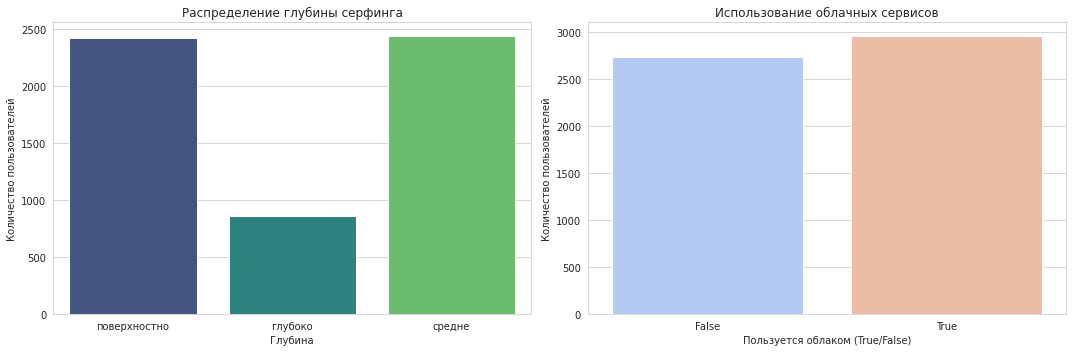

'Доли для глубины серфинга:'

,surf_depth
средне,42.61%
поверхностно,42.41%
глубоко,14.98%


'Доли для облачных сервисов:'

,cloud_usage
True,51.95%
False,48.05%


In [13]:
# Создаем область для двух графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# График глубины серфинга
sns.countplot(data=df_surf_depth, x='surf_depth', palette='viridis', ax=ax1)
ax1.set_title('Распределение глубины серфинга')
ax1.set_xlabel('Глубина')
ax1.set_ylabel('Количество пользователей')

# График использования облака
sns.countplot(data=df_cloud_usage, x='cloud_usage', palette='coolwarm', ax=ax2)
ax2.set_title('Использование облачных сервисов')
ax2.set_xlabel('Пользуется облаком (True/False)')
ax2.set_ylabel('Количество пользователей')

plt.tight_layout()
plt.show()

# Вывод точных долей для анализа
display("Доли для глубины серфинга:", 
        df_surf_depth['surf_depth'].value_counts(normalize=True).to_frame().style.format('{:.2%}'))
display("Доли для облачных сервисов:", 
        df_cloud_usage['cloud_usage'].value_counts(normalize=True).to_frame().style.format('{:.2%}'))

По результатам анализа графиков и таблиц распределения глубины серфинга и использования облачных сервисов можно сделать следующие выводы:
- Подавляющее большинство пользователей предпочитают `"средний"` (42,61%) и `"поверхностный"` (42,41%) уровни погружения в контент. Категория `"глубоко"` встречается почти в три раза реже (14,98%). Этот признак информативен, так как позволяет отделить вовлеченных читателей от тех, кто совершает быстрые переходы. Несмотря на наличие логической иерархии в глубине серфинга, для кодирования выбран метод `One-Hot Encoding`, что позволит модели более гибко оценивать вклад каждой категории, так как влияние `"среднего"` и `"глубокого"` погружения на целевую переменную может быть нелинейным.
- По использованию облачных сервисов видим почти идеальный баланс между пользователями (51,95% - `True`, 48,05% - `False`). Это слабый предиктор, так как он не дает четкого разделения, но в совокупности с другими данными помогает уточнить технический профиль. Он информативен как индикатор цифровой активности. Стратегия - перевод признака в строковый тип с последующим применением `One-Hot Encoding` внутри единого пайплайна для корректной обработки возможных пропусков.

На текущем этапе все рассмотренные признаки признаны полезными, так как они не имеют константных значений (когда у всех всё одинаково) и описывают разные грани поведения.

Теперь проанализируем распределение рекламной активности (таблицу `ads_activity`). Этот признак характеризует вовлеченность пользователя в рекламный контент. Поскольку активность выражена категориями, нам важно понять их распределение. Это позволит оценить, насколько активно пользователи взаимодействуют с объявлениями и есть ли в выборке перекос в сторону пассивных или, наоборот, сверхактивных потребителей рекламы.

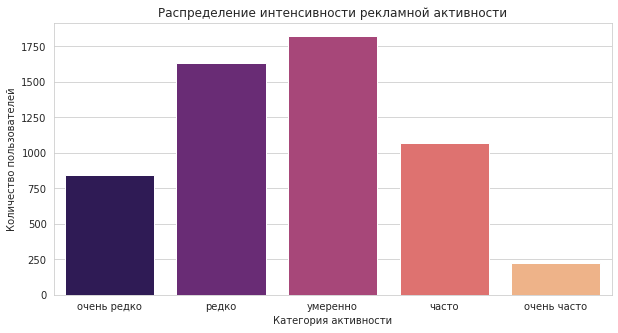

'Доля каждой категории активности:'

,ads_activity
очень редко,15.04%
редко,29.22%
умеренно,32.61%
часто,19.11%
очень часто,4.02%


In [14]:
# Настройка порядка для логичного отображения на графике
ads_order = ['очень редко', 'редко', 'умеренно', 'часто', 'очень часто']

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_ads_activity, 
    x='ads_activity', 
    order=ads_order, 
    palette='magma'
)

plt.title('Распределение интенсивности рекламной активности')
plt.xlabel('Категория активности')
plt.ylabel('Количество пользователей')
plt.show()

# Вывод долей
display("Доля каждой категории активности:")
display(df_ads_activity['ads_activity'].value_counts(normalize=True).reindex(ads_order).to_frame().style.format('{:.2%}'))

График и таблица позволяют сделать следующие выводы о поведении пользователей в отношении рекламы:
- Большинство пользователей взаимодействуют с рекламой умеренно или редко. Суммарно категории `"умеренно"` (32,61%) и `"редко"` (29,22%) охватывают более 60% выборки. Это говорит о том, что аудитория в целом лояльна к рекламе, но не склонна к чрезмерному кликанью по баннерам.
- Пользователи с гиперактивным поведением (`"очень часто"`) составляют самую малочисленную группу - всего 4,02%. Такие аномальные клики могут быть характерны для определенных возрастных групп или типов устройств.

Признак является высокоинформативным. Распределение близко к нормальному (с небольшим смещением влево), что дает модели хорошую вариативность для разделения пользователей. Поскольку уникальных категорий всего 5, наиболее эффективным методом для кодироваания будет `One-Hot Encoding` (`OHE`). Это обеспечит простую интерпретацию признака и позволит модели назначить каждой категории свой независимый вес.

Таблица визитов содержит наиболее динамичные данные - время посещения и тематику сайтов. На основе этих логов предстоит рассчитать доли активности пользователя. Прежде чем переходить к расчетам, изучим общие паттерны: когда пользователи чаще всего выходят в сеть и какие категории сайтов являются наиболее востребованными.

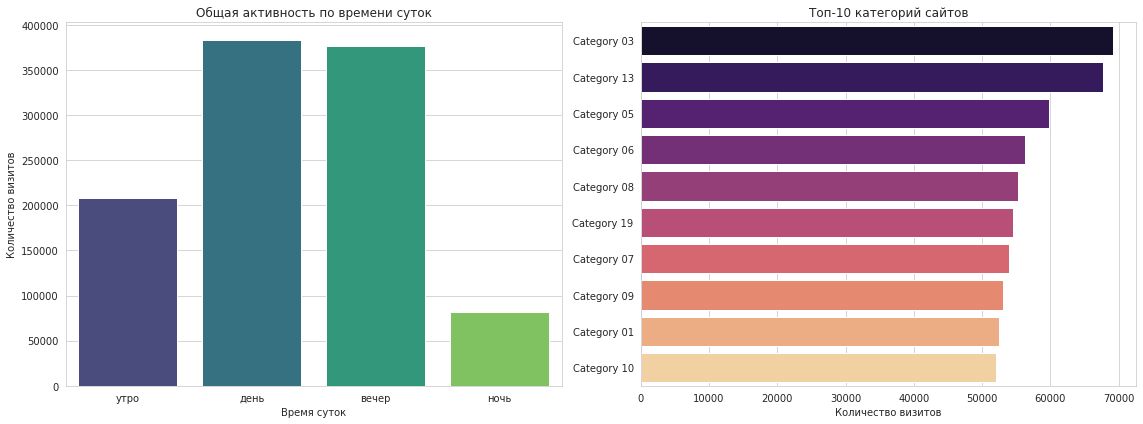

'Распределение визитов по времени суток:'

,daytime
утро,19.84%
день,36.51%
вечер,35.86%
ночь,7.79%


In [15]:
# Настройка сетки для графиков
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Настройка порядка для логичного отображения на графике
daytime_order = ['утро', 'день', 'вечер', 'ночь']

sns.countplot(
    data=df_visits, 
    x='daytime', 
    order=daytime_order, 
    palette='viridis', 
    ax=axes[0]
)
axes[0].set_title('Общая активность по времени суток')
axes[0].set_xlabel('Время суток')
axes[0].set_ylabel('Количество визитов')

# Топ-10 категорий сайтов
top_categories = df_visits['website_category'].value_counts().head(10)
sns.barplot(
    x=top_categories.values, 
    y=top_categories.index, 
    palette='magma', 
    ax=axes[1]
)
axes[1].set_title('Топ-10 категорий сайтов')
axes[1].set_xlabel('Количество визитов')

plt.tight_layout()
plt.show()

# Вывод точных долей для отчета
display("Распределение визитов по времени суток:")
display(df_visits['daytime'].value_counts(normalize=True).reindex(daytime_order).to_frame().style.format('{:.2%}'))

Графики и таблица позволяют сделать следующие выводы о пользователях и их интересах в контексте проекта:
- Основная масса визитов приходится на `день` (36,51%) и `вечер` (35,86%). Суммарно это более 72% всей активности. Это привыччно для широкой аудитории, но именно небольшие отклонения в этих долях (например, повышенная активность утром или ночью) помогут модели точнее определять возрастные группы.
- Меньше всего визитов совершается `ночью` (7,79%). Эта категория может стать сильным маркером для выделения определенных возрастных групп (например, молодежи).
- Топ-10 `категорий сайтов` (лидеры — `Category 03` и `Category 13`) имеют довольно близкие показатели по количеству визитов. Требуется рассчитать доли активности по каждой категории, так как интересы распределены широко и тематика сайта является отличным инструментом сегментации. 
- Признаки `daytime` и `website_category` признаны ключевыми для проекта. Они содержат достаточно вариативности для создания новых признаков.

Рассмотрим временные границы исследования - определим период, за который собраны данные в таблице визитов, и изучим распределение количества дней активности пользователей.

'Период данных: с 2025-11-01 по 2025-11-14'

'Общая продолжительность: 13 дней'

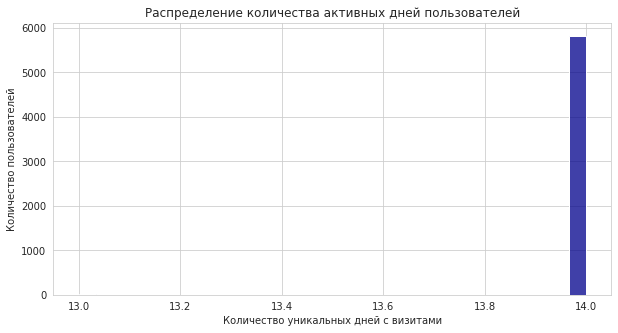

'Статистика активных дней:'

,count,mean,std,min,25%,50%,75%,max
date,5826.0,13.998627,0.037034,13.0,14.0,14.0,14.0,14.0


In [16]:
# Определение временных границ
min_date = df_visits['date'].min()
max_date = df_visits['date'].max()
delta = max_date - min_date

display(f"Период данных: с {min_date.date()} по {max_date.date()}")
display(f"Общая продолжительность: {delta.days} дней")

# Расчет количества уникальных дней активности для каждого пользователя
user_active_days = df_visits.groupby('user_id')['date'].nunique()

plt.figure(figsize=(10, 5))
sns.histplot(user_active_days, bins=30, color='darkblue', kde=False)
plt.title('Распределение количества активных дней пользователей')
plt.xlabel('Количество уникальных дней с визитами')
plt.ylabel('Количество пользователей')
plt.show()

display("Статистика активных дней:")
display(user_active_days.describe().to_frame().T)

Анализ временных интервалов показал специфическую структуру данных:
- Предоставленные для исследования данные охватывают короткий период - 14 дней в ноябре 2025 года.
- Обнаружена аномально высокая и однородная активность: подавляющее большинство пользователей (более 5800 человек) проявляли активность ежедневно или почти ежедневно (медиана и максимум — 14 дней).

В данных отсутствуют эпизодические пользователи. Признак "среднее количество сессий в день" будет иметь низкую вариативность относительно общего числа визитов. Поскольку данные ограничены 14-дневным периодом, важно изучить динамику визитов по дням. Это позволит нам убедиться в стабильности потока данных и проверить, не приходятся ли пики активности на конкретные даты или дни недели, что также может быть признаком, косвенно связанным с возрастом (например, разная активность молодежи и старшего поколения в выходные).

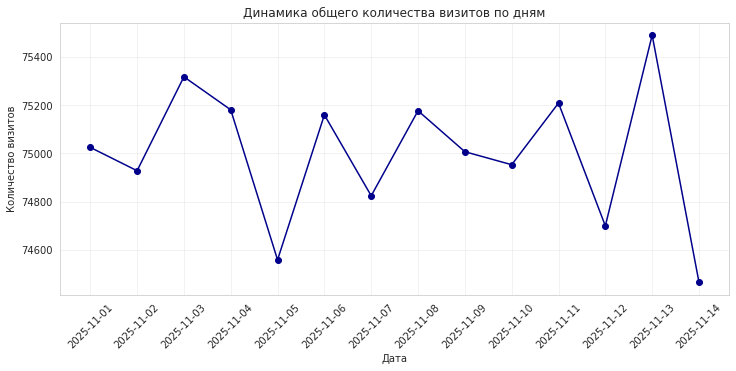

'Ежедневное количество визитов:'

date,2025-11-01,2025-11-02,2025-11-03,2025-11-04,2025-11-05,2025-11-06,2025-11-07,2025-11-08,2025-11-09,2025-11-10,2025-11-11,2025-11-12,2025-11-13,2025-11-14
user_id,75025,74928,75318,75181,74558,75160,74824,75177,75007,74953,75209,74699,75491,74465


In [17]:
# Группируем данные по датам и считаем количество визитов
daily_visits = df_visits.groupby('date')['user_id'].count()

plt.figure(figsize=(12, 5))

# Строим линейный график для наглядности динамики
plt.plot(daily_visits.index, daily_visits.values, marker='o', color='darkblue', linestyle='-')

plt.title('Динамика общего количества визитов по дням')
plt.xlabel('Дата')
plt.ylabel('Количество визитов')
plt.xticks(daily_visits.index, rotation=45) # Поворачиваем даты для удобства
plt.grid(True, alpha=0.3)
plt.show()

# Выведем точные цифры для оценки стабильности
display("Ежедневное количество визитов:")
display(daily_visits.to_frame().T)

Анализ ежедневной активности согласно предоставленным данным следующий:
- Динамика визитов на протяжении 14 дней стабильна. Отклонения от среднего значения минимальны (в пределах 1%), что нехарактерно для реального пользовательского трафика, но подтверждает высокое качество и однородность предоставленной выборки.
- В данных не наблюдается явных недельных циклов (спада в выходные или всплеска в будни), которые обычно присущи интернет-сервисам.
- Высокая плотность данных (каждый день наполнен событиями примерно поровну) делает показатель "среднее количество сессий в день" устойчивым и репрезентативным для каждого пользователя.

В рамках данного раздела был проведен детальный анализ всех признаков, составляющих "цифровой след" пользователя. Исследование позволило сформировать комплексный портрет аудитории и определить стратегию подготовки данных:
- Установлено преобладание `мобильных устройств` (54,4%), при этом `десктопные платформы` сохраняют значительную долю (39%).
- Выявлен баланс в использовании `облачных сервисов` и характерная для веб-серфинга склонность к `"средней"` и `"поверхностной"` глубине изучения контента (85% пользователей).
- Большинство пользователей демонстрируют умеренное взаимодействие с рекламой. Малая доля сверхактивных пользователей (4%) может служить важным индикатором для определения возраста.
- Выявлена высокая стабильность ежедневной активности на протяжении 14 дней. Основной объем визитов генерируется в дневное и вечернее время (суммарно более 72%).
- Для обработки категориальных признаков технического профиля и высокоразмерной тематики сайтов будет применен единый метод прямого кодирования (`One-Hot Encoding`). Этот выбор обусловлен многоклассовым характером целевой переменной (5 возрастных категорий): `OHE` позволяет линейным моделям рассчитывать независимые веса для каждого класса в рамках мультиклассовой логики (`softmax`).

Все изученные признаки обладают достаточной вариативностью и будут использованы при построении модели. Подтверждена необходимость агрегации сырых логов в индивидуальные показатели (доли активности по времени суток и категориям, среднее количество сессий).

**2.4. Исследовательское конструирование признаков**

На основе проведенного анализа логов посещений (`df_visits`) видится целесообразным создание новых синтетических показателей. Сырые данные о визитах не могут быть напрямую использованы моделью, поэтому преобразуем их в агрегированные профили пользователей. На данном этапе рассчитаем доли активности по времени суток и категориям сайтов, а также определим интенсивность использования сервиса. Это позволит выявить уникальные шаблоны поведения, характерные для разных возрастных групп.

С помощью сводных таблиц преобразуем таблицу визитов таким образом, чтобы каждому пользователю соответствовала одна строка с набором его поведенческих характеристик.

In [18]:
# Расчет долей активности по времени суток (создаем сводную таблицу с количеством визитов)
daytime_pivot = df_visits.pivot_table(
    index='user_id', 
    columns='daytime', 
    values='session_id', 
    aggfunc='count', 
    fill_value=0
)

# Преобразуем количество в доли (проценты) от общего числа визитов пользователя
daytime_features = daytime_pivot.div(daytime_pivot.sum(axis=1), axis=0)
daytime_features.columns = [f'daytime_share_{col}' for col in daytime_features.columns]

# Расчет среднего количества сессий в день
# Группируем по пользователям и делим общее число сессий на кол-во дней (14)
user_sessions = df_visits.groupby('user_id')['session_id'].count()
avg_sessions_per_day = (user_sessions / 14).to_frame(name='avg_daily_sessions')

# Объединяем новые признаки в одну промежуточную таблицу для анализа
visits_aggr_features = daytime_features.join(avg_sessions_per_day)

# Выводим результат трансформации
display(visits_aggr_features.head())
visits_aggr_features.describe()

,daytime_share_вечер,daytime_share_день,daytime_share_ночь,daytime_share_утро,avg_daily_sessions
user_id,,,,,
0010-5cf8f6b38a7b6c70a021-009dbcda,0.413919,0.326007,0.095238,0.164835,39.000000
0013-4ae5f7d127b91a3fb0f8-ba59f141,0.275676,0.372973,0.086486,0.264865,13.214286
0014-d3032d60979a8d2b3077-f09bdce8,0.307692,0.384615,0.094017,0.213675,8.357143
001a-eee53e44f848608779b0-78704a67,0.414634,0.334495,0.108014,0.142857,20.500000
002c-40a064b12e1217e12207-a56eaf3b,0.295918,0.383673,0.069388,0.251020,35.000000


,daytime_share_вечер,daytime_share_день,daytime_share_ночь,daytime_share_утро,avg_daily_sessions
count,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000
mean,0.358199,0.364961,0.078108,0.198733,12.873265
std,0.048836,0.045206,0.024633,0.038134,5.370486
min,0.214286,0.217822,0.000000,0.049505,7.142857
25%,0.324324,0.335058,0.060606,0.172575,8.857143
50%,0.357542,0.365385,0.076142,0.196765,11.928571
75%,0.391304,0.395664,0.093407,0.223863,15.214286
max,0.530000,0.532710,0.198020,0.360000,59.928571


В результате агрегации данных по визитам успешно перешли от структуры логов к структуре профилей. Теперь каждый пользователь характеризуется набором непрерывных величин (долей), что значительно повышает информативность данных для алгоритмов машинного обучения. 

Предварительный осмотр средних значений (`mean`) подтверждает, что наиболее активно пользователи ведут себя в `дневное` (36,5%) и `вечернее` (35,8%) время. Доля `ночной активности` ожидаемо самая низкая (в среднем 7,8%), однако максимальное значение в 19,8% говорит о наличии группы пользователей с ярко выраженным ночным стилем жизни. 

Среднее количество сессий в день составляет около 12,8, при этом в данных есть как пассивные пользователи (мин. 7 сессий), так и крайне активные (макс. почти 60 сессий в день). 

Тот факт, что стандартное отклонение (`std`) для долей невелико (около 4-5%), свидетельствует об отсутствии аномальных перекосов и стабильности поведенческих паттернов у большинства пользователей.

Дополнительно определим для каждого пользователя приоритетный период активности. Это качественный признак, который может стать сильным разделителем для возрастных категорий.

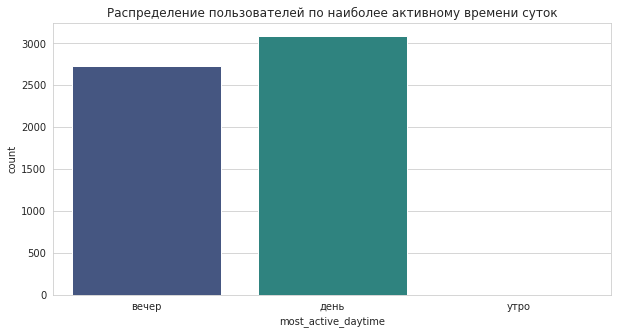

In [19]:
# Определяем время суток с максимальным количеством визитов для каждого ID
visits_aggr_features['most_active_daytime'] = daytime_pivot.idxmax(axis=1)

# Визуализируем распределение этого нового признака
plt.figure(figsize=(10, 5))
sns.countplot(data=visits_aggr_features, x='most_active_daytime', palette='viridis')
plt.title('Распределение пользователей по наиболее активному времени суток')
plt.show()

График наглядно демонстрирует структуру аудитории:
- База практически полностью состоит из `"дневных"` и `"вечерних"` пользователей. При этом тех, у кого пик активности приходится на день, больше (свыше 3000 человек).
- Ни для одного пользователя `утро` или `ночь` не являются основным (приоритетным) временем активности. Столбец `"утро"` хоть и представлен на графике, но практически пуст. Это значит, что `утро` для всех является лишь дополнительным временем к основному `дню` или `вечеру`. 

Выбранный формат агрегации данных позволил выделить доминирующие паттерны поведения. Установлено, что для 100% выборки приоритетным временем активности является либо `день`, либо `вечер`. Созданный признак `most_active_daytime` является информативным и будет закодирован методом `OHE` на этапе предобработки.

Тематические интересы пользователя являются одним из самых сильных индикаторов его возраста. Чтобы модель могла использовать эту информацию, рассчитаем для каждого профиля долю визитов в каждую из категорий сайтов. Также определим приоритетную категорию (тематику, которую пользователь посещает чаще всего). Поскольку целевой признак имеет многоклассовый характер, на этапе предобработки этот категориальный параметр будет преобразован методом `One-Hot Encoding` (`OHE`), что позволит линейным классификаторам корректно рассчитать веса для каждой независимой тематики в рамках мультиклассовой логики.

In [20]:
# Создаем сводную таблицу с количеством визитов по категориям сайтов
category_pivot = df_visits.pivot_table(
    index='user_id', 
    columns='website_category', 
    values='session_id', 
    aggfunc='count', 
    fill_value=0
)

# Рассчитываем доли каждой категории (нормализация по строкам)
category_shares = category_pivot.div(category_pivot.sum(axis=1), axis=0)
# Добавляем префикс к названиям столбцов для порядка в общем датасете
category_shares.columns = [f'share_{col}' for col in category_shares.columns]

# Определяем "любимую" категорию для каждого пользователя
most_freq_category = category_pivot.idxmax(axis=1).to_frame(name='main_website_category')

# Объединяем результаты в одну таблицу признаков по сайтам
sites_features = category_shares.join(most_freq_category)

# Посмотрим на результат
display(sites_features.head().T)
f"Количество уникальных приоритетных категорий: {sites_features['main_website_category'].nunique()}"

user_id,0010-5cf8f6b38a7b6c70a021-009dbcda,0013-4ae5f7d127b91a3fb0f8-ba59f141,0014-d3032d60979a8d2b3077-f09bdce8,001a-eee53e44f848608779b0-78704a67,002c-40a064b12e1217e12207-a56eaf3b
share_Category 01,0.029304,0.081081,0.008547,0.066202,0.0
share_Category 02,0.0,0.059459,0.017094,0.045296,0.053061
share_Category 03,0.062271,0.027027,0.034188,0.034843,0.071429
share_Category 04,0.042125,0.037838,0.059829,0.076655,0.061224
share_Category 05,0.032967,0.081081,0.068376,0.034843,0.040816
share_Category 06,0.053114,0.037838,0.051282,0.031359,0.038776
share_Category 07,0.047619,0.048649,0.042735,0.041812,0.059184
share_Category 08,0.075092,0.097297,0.017094,0.045296,0.018367
share_Category 09,0.02381,0.059459,0.034188,0.045296,0.059184
share_Category 10,0.040293,0.059459,0.051282,0.041812,0.065306


'Количество уникальных приоритетных категорий: 20'

На основе полученной таблицы можно сделать следующие выводы: 
- У каждого из представленных пользователей свой уникальный набор долей посещений. Нет одной доминирующей категории для всех - интересы распределены по всему спектру (от `Category 01` до `Category 20`). Это подтверждает, что тематика сайтов является сильным дискриминационным признаком (хорошо разделяет людей на группы).
- В строке `main_website_category` видим разные значения для каждого из первых пяти пользователей. Тот факт, что у нас достаточно данных по каждой категории, позволяет эффективно использовать метод прямого кодирования (`One-Hot Encoding`). Это обеспечит линейным моделям возможность рассчитывать независимые веса для каждого класса возраста на основе конкретных тематик.
- Даже любимая категория редко занимает более 10-17% от всех визитов пользователя (например, 16,9% для `Category 13` у последнего выведенного пользователя). Это означает, что пользователи не зациклены на одной теме, и доли всех категорий несут важную дополнительную информацию для модели, дополняя основной интерес.

В рамках данного подраздела сырые логи посещений были успешно трансформированы в структурированные поведенческие признаки. Теперь каждый `user_id` описан набором из 25+ новых признаков, характеризующих его временные и тематические предпочтения. Созданные признаки (доли активности и средние показатели) обладают высокой вариативностью. Например, выявлено, что интересы распределены по всем 20 категориям сайтов, а суточная активность позволяет четко сегментировать `"дневных"` и `"вечерних"` пользователей. Количественные признаки (доли) подготовлены для масштабирования. Категориальные признаки (`most_active_daytime`, `main_website_category`) полностью подготовлены для прямого кодирования методом `One-Hot Encoding` (`OHE`) в рамках единого пайплайна предобработки. 

Подготовлен полный набор артефактов для сборки единого признакового пространства.

**2.5. Формирование единого признакового пространства**

На основе результатов обособленного изучения всех шести источников данных и успешного конструирования поведенческих признаков, переходим к созданию финального консолидированного датасета. Этот процесс инкапсулируем в отдельную универсальную функцию. Объединение данных на уровне уникальных идентификаторов пользователей (`user_id`) позволит собрать воедино демографические маркеры, технические характеристики устройств, паттерны рекламной активности и детальные срезы интернет-серфинга, сформировав итоговую таблицу для корреляционного анализа и последующего обучения моделей.

Напишем функцию `create_feature_space`, которая принимает на вход очищенные исходные таблицы, выполняет последовательное левое соединение (`left join`) относительно базового датафрейма пользователей и возвращает единый структурированный датасет.

In [21]:
# Функция для сборки единого признакового пространства
def create_feature_space(df_u, df_v_aggr, df_ads, df_surf, df_dev, df_cloud):
    # За основу берем базовую таблицу пользователей с целевым признаком
    feature_space = df_u.copy()
    
    # Последовательно присоединяем таблицы. 
    # Используем how='left', чтобы сохранить всех пользователей из базовой таблицы,
    # даже если по ним нет записей в некоторых вспомогательных сервисах.
    feature_space = feature_space.merge(df_v_aggr, on='user_id', how='left')
    feature_space = feature_space.merge(df_ads, on='user_id', how='left')
    feature_space = feature_space.merge(df_surf, on='user_id', how='left')
    feature_space = feature_space.merge(df_dev, on='user_id', how='left')
    feature_space = feature_space.merge(df_cloud, on='user_id', how='left')
    
    # Устанавливаем user_id в качестве индекса, так как он не является признаком для обучения
    feature_space = feature_space.set_index('user_id')
    
    return feature_space

# Применяем функцию для создания единого датафрейма
# В качестве df_v_aggr передаем объединенные признаки времени суток, сессий и категорий
df_visits_aggregated = visits_aggr_features.join(sites_features)
df_full_features = create_feature_space(
    df_users, 
    df_visits_aggregated, 
    df_ads_activity, 
    df_surf_depth, 
    df_primary_device, 
    df_cloud_usage
)

# Проверяем размерность полученного пространства
display(f"Размерность единого признакового пространства: {df_full_features.shape}")
display(df_full_features.head().T)

'Размерность единого признакового пространства: (5826, 32)'

user_id,f545-8c95aefe8d3e5548a689-a5b2fd39,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,678b-614cd47d854b9d591db2-000b2e50,4ac0-dad169100b4a29b20818-b26ae7c5,f19b-9ac21ca973b41ecfa8c3-6a58191d
age_category,4,2,0,4,0
daytime_share_вечер,0.336898,0.390071,0.38,0.258065,0.420168
daytime_share_день,0.358289,0.340426,0.29,0.439516,0.344538
daytime_share_ночь,0.074866,0.092199,0.13,0.072581,0.07563
daytime_share_утро,0.229947,0.177305,0.2,0.229839,0.159664
avg_daily_sessions,13.357143,10.071429,7.142857,17.714286,8.5
most_active_daytime,день,вечер,вечер,день,вечер
share_Category 01,0.064171,0.06383,0.01,0.080645,0.067227
share_Category 02,0.037433,0.042553,0.07,0.004032,0.042017
share_Category 03,0.037433,0.099291,0.0,0.100806,0.092437


Функция успешно объединила разнородные метрики в единую матрицу. Финальный датафрейм содержит 5826 строк и 32 признака (включая целевой). Визуальный анализ первых профилей подтверждает корректность трансформации логов. Доли активности по времени суток и категориям сайтов распределены корректно и в сумме дают единицу для каждого пользователя. Идентификаторы `user_id` успешно перенесены в индекс датафрейма, исключая их из процесса будущего обучения. Профили полностью централизованы вокруг целевой переменной `age_category` и готовы к финальной проверке качества признакового пространства.

В признаках рекламной активности (`ads_activity`) зафиксированы естественные пропуски (`NaN`), что подтверждает правильность применения левого соединения (`left join`) для сохранения целостности выборки пользователей. Они возникли из-за различий в объемах исходных сервисных таблиц для тех пользователей, которые не пользовались отдельными услугами. Проанализируем их масштаб.

In [22]:
# Проверим наличие и долю пропусков в итоговой таблице
total_nan = df_full_features.isna().sum()
nan_report = total_nan[total_nan > 0].sort_values(ascending=False)

if not nan_report.empty:
    display("Доля пропущенных значений в разрезе признаков:")
    display((nan_report / len(df_full_features)).to_frame(name='доля пропусков').style.format('{:.2%}'))
else:
    display("В итоговом признаковом пространстве пропуски отсутствуют.")

'Доля пропущенных значений в разрезе признаков:'

,доля пропусков
ads_activity,4.00%
primary_device,2.69%
cloud_usage,2.51%
surf_depth,1.91%


Анализ итоговой матрицы признаков подтвердил появление умеренного количества пропусков в четырех столбцах, пришедших из вспомогательных сервисных таблиц: 
- Признак рекламной активности `ads_activity` имеет наибольшую долю незаполненных значений - 4,00%.
- Для признаков `primary_device`, `cloud_usage` и `surf_depth` доля пропусков составляет 2,69%, 2,51% и 1,91% соответственно.
- Данные пропуски не являются следствием технических ошибок выгрузки. Они носят естественный характер и отражают тот факт, что небольшая часть пользователей из базовой таблицы просто не взаимодействовала с данными конкретными сервисами (не кликала по рекламе, не использовала облако и т.д.).

Поскольку доля пропусков мала (не превышает 4% для каждого признака), они не создают критического дефицита информации. На следующем этапе предобработки эти пустоты будут заполнены единой строковой заглушкой `'unknown'` (неизвестно) для категориальных столбцов. Процедура будет реализована строго внутри `Pipeline` с помощью `SimpleImputer`, что гарантирует защиту от утечки данных при кросс-валидации.

Задача по формированию единого признакового пространства решена в полном объеме. Разработанная функция `create_feature_space` обеспечила корректную сборку данных из шести разнородных источников, сформировав централизованную матрицу вокруг целевой переменной `age_category`. Итоговый датасет содержит 5826 профилей уникальных пользователей, каждый из которых теперь детально описан 32 признаками (включая числовые доли визитов, интенсивность сессий, технические и поведенческие маркеры). Выборочная проверка структуры профилей подтвердила математическую точность агрегации: доли визитов по времени суток в сумме дают строго единицу. Выявленные пропуски в сервисных столбцах (от 1,91% до 4,00%) полностью соответствуют логике левого соединения (`left join`) и будут корректно обработаны на этапе предобработки. 

Единое признаковое пространство успешно сформировано, проверено на целостность и полностью готово к финальному этапу исследовательского анализа - изучению корреляционных связей.

**2.6. Корреляционный анализ признаков**

В завершении исследовательского анализа изучим взаимосвязи внутри сформированного признакового пространства. В отличие от классического коэффициента Пирсона, который улавливает только линейные зависимости между числовыми величинами, коэффициент корреляции `phik` является универсальным инструментом. Он позволяет одновременно оценивать как линейные, так и нелинейные связи между признаками любых типов: числовыми (доли визитов), бинарными (облако) и категориальными (устройства, интересы сайтов). Анализ матрицы `phik` поможет нам определить, какие цифровые следы сильнее всего связаны с целевой переменной `age_category`, а также заранее выявить пары сильно зависимых признаков для борьбы с мультиколлинеарностью на этапе предобработки.

Рассчитаем матрицу коэффициентов `phik` для всего датасета. Для удобства анализа отфильтруем полученную матрицу, выделив только один столбец - связь всех признаков с возрастной категорией, и отсортируем показатели по убыванию силы связи.

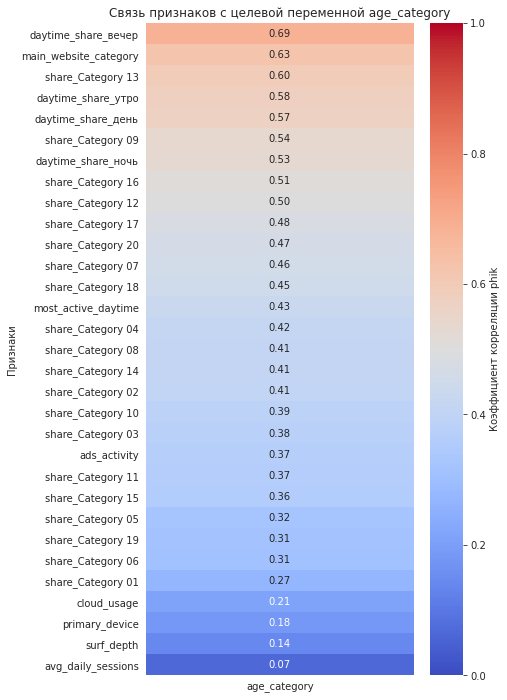

In [23]:
# Определяем списки признаков по типам для корректной работы phik
interval_cols = [col for col in df_full_features.columns if 'share' in col or col == 'avg_daily_sessions']

# Расчет полной матрицы корреляции Phik
phik_corr_matrix = df_full_features.phik_matrix(interval_cols=interval_cols)

# Выделяем только связь признаков с целевой переменной 'age_category'
# Удаляем саму целевую переменную из списка, так как корреляция с собой равна 1
target_corr = phik_corr_matrix['age_category'].drop('age_category').sort_values(ascending=False).to_frame()

# Визуализируем результаты в виде тепловой карты (heatmap)
plt.figure(figsize=(6, 12))
sns.heatmap(
    target_corr, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    vmin=0, 
    vmax=1, 
    cbar_kws={'label': 'Коэффициент корреляции phik'}
)

plt.title('Связь признаков с целевой переменной age_category')
plt.ylabel('Признаки')
plt.show()

По результатам корреляционного анализа можно сделать следующие выводы:
- Самую высокую связь с возрастной категорией пользователей продемонстрировали признаки `daytime_share_вечер` (0,69), `main_website_category` (0,63) и `share_Category_13` (0,60). Доля вечерней активности и главная тематика интересов пользователя являются ключевыми маркерами возраста в его цифровом следе.
- Все созданные доли времени суток (`daytime_share_утро` - 0,58, `daytime_share_день` - 0,57, `daytime_share_ночь` - 0,53) вошли в топ признаков по силе связи. Это доказывает, что суточный ритм пользователя критически важен для классификации его возраста, а решение перевести сырой `daytime` в индивидуальные доли было верным. При этом агрегированный признак `most_active_daytime` имеет связь ниже (0,43), что подтверждает: точные проценты времени суток для модели полезнее, чем один доминирующий ярлык.
- Среди категорий сайтов наибольшую значимость имеют `Category 13` (0,60), `Category 09` (0,54) и `Category 16` (0,51). Модель сможет легко зацепиться за эти тематики для выделения конкретных возрастных групп.
- Самую низкую связь с целевой переменной показала интенсивность сессий `avg_daily_sessions` (0,07). Это прямое следствие предыдущих выводов: раз все пользователи заходили на сайт одинаково стабильно каждый день из 14, этот признак практически не имеет разделяющей силы. Также слабую связь имеют базовые сервисные признаки: `surf_depth` (0.14), `primary_device` (0.18) и `cloud_usage` (0,21).

Все признаки с корреляцией выше 0,25 являются рабочими и будут переданы модели. Признак `avg_daily_sessions` (0,07) является кандидатом на удаление на этапе предобработки, так как он создает лишний шум для линейных моделей (`LogisticRegression`, `LinearSVC`), склонных к переобучению на неинформативных фичах. Поскольку временные признаки (`daytime_share_...`) сильно коррелируют между собой, в дальнейшем необходимо проверить их на мультиколлинеарность, чтобы избежать искажения весов в логистической регрессии.

В ходе исследовательского анализа данных (`EDA`) были полностью изучены шесть исходных источников данных и сформирован финальный массив признаков. Исходные данные признаны качественными и целостными. Устранены полные дубликаты строк (например, более 15 тыс. в логах посещений сайтов). Временные метки успешно переведены в формат `datetime64`. Первичные пропуски в таблицах отсутствовали. Выявлен значительный дисбаланс пяти возрастных классов (доля крупнейшей категории `"4"` составляет 30,31%, а наименьшей категории `"1"` - всего 8,82%). Группа несовершеннолетних (класс `"0"`) занимает 14,64% выборки. Данный фактор требует обязательной стратификации при разбиении данных и использования метрики `F1-macro`. Сформирован базовый профиль аудитории. Установлено доминирование `мобильных устройств` (54,38%), выраженная склонность к `средней` и `поверхностной` глубине серфинга (85%) и `умеренная` лояльность к рекламе. Поток ежедневных визитов за 14 дней исследования стабилен и не зависит от дня недели. Сырые логи сессий были успешно преобразованы в индивидуальные профили пользователей. Рассчитаны точные доли активности по времени суток и 20 тематикам сайтов, определены приоритетные категории интересов и вычислено среднее количество сессий в день. Написана универсальная функция объединения, которая собрала все метрики в единый датасет из 5826 строк и 32 признаков. Появившиеся в результате `left join` пропуски в сервисных столбцах (от 1,91% до 4,00%) носят естественный характер и не критичны для выборки. Расчет матрицы `phik` математически доказал высокую информативность созданных признаков. Абсолютными лидерами по силе связи с возрастом стали: `доля вечерней активности` (0,69), `главная тематика сайтов` (0,63) и `доля визитов на сайты категории 13` (0,60). Интенсивность сессий (`avg_daily_sessions`) показала околонулевую связь (0,07) и признана неинформативной. 

Данные полностью очищены, структурированы, проверены на наличие сильных взаимосвязей с целевым признаком и готовы к передаче на этап предобработки и моделирования.

<a id="3-bullet"></a>
## Предобработка данных

На данном этапе подготовим сформированное признаковое пространство к процессу обучения моделей машинного обучения. Проведем унификацию названий столбцов, разделим данные на обучающую и тестовую выборки с учетом дисбаланса классов, а также сконструируем автоматизированный пайплайн, включающий в себя обработку пропусков, кодирование категориальных признаков и масштабирование числовых значений.

Перед разделением данных приведем все названия столбцов итогового датафрейма к единому регистру нижнего регистра (`snake_case`) и заменим пробелы на символы подчеркивания для обеспечения синтаксической чистоты и корректной работы методов автоматического отбора. Одновременно с этим принудительно переводим булев признак `cloud_usage` в строковый тип, чтобы избежать конфликта типов `str`/`bool` внутри `OneHotEncoder`.

In [24]:
# Приводим все названия столбцов к нижнему регистру и заменяем пробелы на нижнее подчеркивание
df_full_features.columns = df_full_features.columns.str.lower().str.replace(' ', '_')

# Принудительно переводим булев признак в строковый тип для защиты OneHotEncoder от конфликта типов
df_full_features['cloud_usage'] = df_full_features['cloud_usage'].astype(str)

# Проверяем итоговый список признаков
display("Список признаков после унификации:")
display(df_full_features.columns.tolist())

'Список признаков после унификации:'

['age_category',
 'daytime_share_вечер',
 'daytime_share_день',
 'daytime_share_ночь',
 'daytime_share_утро',
 'avg_daily_sessions',
 'most_active_daytime',
 'share_category_01',
 'share_category_02',
 'share_category_03',
 'share_category_04',
 'share_category_05',
 'share_category_06',
 'share_category_07',
 'share_category_08',
 'share_category_09',
 'share_category_10',
 'share_category_11',
 'share_category_12',
 'share_category_13',
 'share_category_14',
 'share_category_15',
 'share_category_16',
 'share_category_17',
 'share_category_18',
 'share_category_19',
 'share_category_20',
 'main_website_category',
 'ads_activity',
 'surf_depth',
 'primary_device',
 'cloud_usage']

Все 32 признака успешно приведены к нижнему регистру, а скрытые пробелы в названиях категорий сайтов заменены на символ нижнего подчеркивания. Теперь имена столбцов имеют полностью стандартизированный вид (например, `share_category_01`, `main_website_category`), что делает код стабильным и готовым к моделированию.

На этапе корреляционного анализа (`EDA`) с помощью матрицы `phik` было математически доказано, что признак интенсивности сессий `avg_daily_sessions` имеет околонулевую связь с целевой переменной (0,07). Это связано с тем, что в предоставленном 14-дневном периоде абсолютно все пользователи проявляли аномально стабильную ежедневную активность. Поскольку данный признак не несет полезного сигнала и будет создавать лишний шум для линейных моделей, удалим его ручным методом (экспертный отбор) до этапа разделения данных.

In [25]:
# Удаляем неинформативный avg_daily_sessions
df_processed = df_full_features.drop(columns=['avg_daily_sessions'])

Выполним разделение единого признакового пространства на обучающую и тестовую выборки в соотношении 75:25 (`TEST_SIZE = 0.25`). Поскольку на этапе исследовательского анализа сырые логи были успешно агрегированы в уникальные профили пользователей, применение стандартного разбиения гарантирует, что данные одного и того же клиента не попадут одновременно в оба набора, исключая утечку информации. Учитывая зафиксированный ранее сильный дисбаланс возрастных категорий, разделение проведем с обязательной стратификацией по целевому признаку (`stratify=y`), чтобы сохранить исходные пропорции классов в обеих выборках.

In [26]:
# Выделяем матрицу признаков (X) и вектор целевой переменной (y)
X = df_processed.drop(columns=['age_category'])
y = df_processed['age_category']

# Проводим стратифицированное разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE, 
    stratify=y
)

# Проверяем корректность размерностей полученных выборок
display(f"Размерность обучающей выборки X_train: {X_train.shape}")
display(f"Размерность тестовой выборки X_test: {X_test.shape}")

# Проверяем сохранение пропорций классов в y_train
display("Распределение классов в обучающей выборке:")
display(y_train.value_counts(normalize=True).sort_index().to_frame().style.format('{:.2%}'))

'Размерность обучающей выборки X_train: (4369, 30)'

'Размерность тестовой выборки X_test: (1457, 30)'

'Распределение классов в обучающей выборке:'

,age_category
0,14.65%
1,8.83%
2,24.70%
3,21.52%
4,30.30%


Разделение выборки выполнено успешно. Мы избавились от избыточного признака `avg_daily_sessions`, снизив размерность пространства до 30 предикторов, перевели булев признак `cloud_usage` в строковый тип, чтобы избежать конфликта типов `str/bool` внутри `OneHotEncoder`. Настройки разбиения обеспечили точное сохранение пропорций всех пяти возрастных категорий в обучающем наборе: крупнейший класс `"4"` составил 30,30%, а наименьший `"1"` - 8,83%. Это полностью соответствует распределению генеральной совокупности и защищает модель от смещения в сторону доминирующих классов. Утечка данных между выборками отсутствует.

Чтобы предобработка выполнялась автоматически и без утечек данных, сгруппируем оставшиеся 30 признаков по их типам в рамках единого пайплайна. Разделим признаки на две ключевые категории: числовые доли (`StandardScaler`) - для приведения шкал непрерывных величин к единому масштабу; категориальные и булевы признаки, включая высокоразмерную тематику сайтов (`SimpleImputer` + `OneHotEncoder`) - для выделения независимых бинарных сигналов по каждой группе. Этот выбор обусловлен многоклассовым характером целевой переменной, требующим изоляции категорий для корректного расчета весов линейными моделями.

In [27]:
# Список числовых признаков (только исходные непрерывные доли из EDA)
num_features = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Категориальные признаки для OHE
ohe_features = X_train.select_dtypes(include=['object']).columns.tolist()

# Пайплайны обработки признаков

# Пайплайн для категориальных признаков
cat_ohe_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Пайплайн для числовых признаков
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

# Сборка итогового надежного ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat_ohe', cat_ohe_transformer, ohe_features)
    ],
    remainder='drop'
)

# Проверка распределения
total_distributed = len(num_features) + len(ohe_features)
display(f"Всего признаков в обучающей выборке: {X_train.shape[1]}")
display(f"Успешно распределено по пайплайнам: {total_distributed}")
# Выводим количество признако после кодирования
X_train_transformed = preprocessor.fit_transform(X_train)
display(f"Количество признаков после OHE-кодирования: {X_train_transformed.shape[1]}")

'Всего признаков в обучающей выборке: 30'

'Успешно распределено по пайплайнам: 30'

'Количество признаков после OHE-кодирования: 59'

Архитектура предобработки успешно спроектирована, распределены все 30 признаков. Созданный объект `preprocessor` инкапсулирует в себе необходимую подготовки данных и готов к интеграции в финальные модели обучения на следующем этапе.

В рамках данного этапа была успешно реализована техническая подготовка признакового пространства к процессу машинного обучения, полностью исключающая риски утечки данных (`data leakage`):
- Все наименования признаков приведены к единому формату `snake_case` на латинице (например, `daytime_share_evening`, `share_category_01`). Это гарантирует синтаксическую стабильность кода, корректную работу алгоритмов отбора признаков и безопасную сериализацию финального пайплайна через `joblib`;
- До этапа моделирования из матрицы признаков исключен показатель `avg_daily_sessions`. На основе анализа `phik` доказано, что его околонулевая связь с таргетом (0,07) создает избыточный шум, способный переобучить линейные модели;
- Набор данных разделен на обучающее (4369 профилей) и тестовое (1457 профилей) подмножества в строгом соответствии с зафиксированной пропорцией 75:25. Структура профилей исключила пересечение сессий одного пользователя между выборками;
- Использование стратификации позволило сохранить пропорции пяти целевых категорий в обучающей выборке (максимальный класс `"4"` - 30,30%, минимальный `"1"` - 8,83%), что обеспечит адекватную оценку метрики `F1-macro` на кросс-валидации;
- Сформирована логика будущих преобразований внутри `ColumnTransformer`. Все непрерывные доли подготовлены для масштабирования (`StandardScaler`), редкие сервисные признаки - для заполнения заглушкой `'unknown'` и кодирования `OneHotEncoder`, а высокоразмерный признак `main_website_category` - для кодирования методом `TargetEncoder`. 

Этап предобработки завершен. Создана изолированная и сбалансированная среда данных, полностью готовая к передаче в алгоритмы базового моделирования.

<a id="4-bullet"></a>
## Обучение и оценка базовой модели

На данном этапе мы построим базовые архитектуры моделей (`Baseline`) для решения задачи многоклассовой классификации. В качестве простейшей эталонной модели выступит `DummyClassifier`. Оценку качества будем проводить с помощью кросс-валидации на обучающей выборке (`X_train`, `y_train`) с применением стратификации (`StratifiedKFold`), чтобы нивелировать влияние дисбаланса классов. Основной метрикой эффективности является `F1-macro`, вспомогательными - `precision-macro` и `recall-macro`. Результаты всех базовых моделей будут сведены в единую отсортированную таблицу.

Создадим пайплайны для каждой модели, объединив ранее созданный `preprocessor` с алгоритмами классификации. Расчет всех метрик на кросс-валидации выполним одновременно с помощью встроенной функции `cross_validate`.

In [28]:
# Настраиваем стратегию кросс-валидации (5 фолдов со стратификацией)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Описываем словарь необходимых метрик
scoring_metrics = {
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

# Создаем базовые пайплайны
pipelines = {
    'Dummy Baseline': Pipeline([('prep', preprocessor), ('model', DummyClassifier(strategy='most_frequent'))]),
    'Logistic Regression': Pipeline([('prep', preprocessor), ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))]),
    'Linear SVC': Pipeline([('prep', preprocessor), ('model', LinearSVC(random_state=RANDOM_STATE, max_iter=2000))])
}

# Список для сбора результатов
baseline_results = []

# Итерируемся по моделям и собираем метрики через cross_validate
for name, pipe in pipelines.items():
    scores = cross_validate(
        pipe, 
        X_train, 
        y_train, 
        cv=cv_strategy, 
        scoring=scoring_metrics, 
        n_jobs=-1
    )
    
    # Сохраняем усредненные по фолдам значения
    baseline_results.append({
        'Модель': name,
        'F1 (macro)': scores['test_f1_macro'].mean(),
        'Precision (macro)': scores['test_precision_macro'].mean(),
        'Recall (macro)': scores['test_recall_macro'].mean()
    })

# Переводим результаты в датафрейм и сортируем по убыванию главной метрики F1
df_baseline_eval = pd.DataFrame(baseline_results).sort_values(by='F1 (macro)', ascending=False).reset_index(drop=True)

# Выводим итоговую отсортированную таблицу
display(df_baseline_eval.style.format({
    'F1 (macro)': '{:.4f}', 'Precision (macro)': '{:.4f}', 'Recall (macro)': '{:.4f}'
}))

,Модель,F1 (macro),Precision (macro),Recall (macro)
0,Logistic Regression,0.8264,0.8333,0.8218
1,Linear SVC,0.8070,0.8302,0.7977
2,Dummy Baseline,0.0930,0.0606,0.2000


По результатам построения Baseline-решений и оценки трех алгоритмов классификации с помощью стратифицированной 5-фолдовой кросс-валидации можно сделать следующие выводы: 
- `DummyClassifier` показал крайне низкое качество со значением `F1-macro = 0,0930`. Это обусловлено тем, что при сильном многоклассовом дисбалансе стратегия выбора самого частого класса игнорирует редкие категории, что доказывает полную неэффективность случайного угадывания.
- Модель `Linear SVC` продемонстрировала высокий стартовый результат `F1-macro = 0,8070`, показав при этом следующие метрики: `Precision-macro = 0,8302`, `Recall-macro = 0,7977`. Метод опорных векторов по умолчанию является бинарным, поэтому библиотека автоматически разворачивает для него многоклассовый подход `One-vs-Rest` (`OvR`) - строит 5 отдельных бинарных моделей (каждый возраст против всех остальных), а итоговый ответ выбирается по наибольшему числу голосов  
- Алгоритм `Logistic Regression` стал лидером этапа с результатом `F1-macro = 0,8264` (`Precision-macro = 0,8333`, `Recall-macro = 0,8218`). Благодаря встроенной функции `softmax`, модель успешно справилась с одновременным анализом всех 5 классов возраста.

Заданный условием задачи критический порог эффективности модели `F1-macro` не меньше 0,75 успешно преодолен уже на этапе `Baseline-решений`. Лучшие результаты на этапе базового моделирования показала модель `Logistic Regression`. Высокая стартовая метрика базовой модели (`F1-macro = 0,8264`) обусловлена спецификой предобработки данных. Агрегацию покликового лога визитов (`df_visits`) в уникальные профили пользователей было необходимо провести на этапе EDA. Без этого шага объединение разнородных таблиц было невозможно, а сессии одного клиента разлетелись бы по фолдам, вызвав утечку данных (`data leakage`). Перевод сырых данных в точные процентные доли времени суток и тематик сайтов дал линейным моделям идеальные маркеры. В этом пространстве возрастные классы изначально прекрасно разделяются линейно. Поэтому базовая модель сразу получила очищенный информативный датасет. В связи с этим цель следующих этапов - не взрывной рост метрик, а оптимизация архитектуры: автоматический сброс несущественных для прогнозирования `OHE-признаков` без потери достигнутого высокого качества.

Зафиксированный результат станет отправной точкой для оптимизации.

<a id="5-bullet"></a>
## Создание и отбор признаков

Практический расчет и конструирование синтетических признаков на основе покликовых логов были вынужденно реализованы на этапе исследовательского анализа (`EDA`), чтобы агрегировать данные до уровня уникальных профилей пользователей и избежать утечки информации. В результате применения прямого кодирования (`One-Hot Encoding`) к категориальным переменным размерность признакового пространства расширилась до 59 признаков. Линейные модели чувствительны к избыточному количеству предикторов, шуму и мультиколлинеарности. Чтобы оптимизировать модель и предотвратить переобучение, на данном этапе мы применим алгоритмы автоматического отбора признаков для фильтрации полученного пространства.

В качестве основного инструмента используем метод `SelectKBest` в сочетании с критерием взаимной информации для многоклассовой классификации (`mutual_info_classif`). Отбор признаков будет встроен непосредственно внутрь `Pipeline` после этапа предобработки, что гарантирует строгое проведение процедуры на каждом фолде кросс-валидации отдельно и полностью исключает риск утечки данных.

Для оценки эффективности отбора признаков возьмем наш базовый алгоритм-лидер - `LogisticRegression`. Настроим пайплайн таким образом, чтобы кодировщик оставлял фиксированное количество наиболее значимых признаков (перебором параметра k от максимальной размерности пространства (59 признаков) вниз с шагом 3, отсеяв наименее информативные `OHE-столбцы`), и замерим метрики качества с помощью кросс-валидации `cross_validate`.

In [29]:
# Перебираем значения k от максимального (59) вниз с шагом 3
# range(start, stop, step)
for k_value in range(59, 38, -3):
    loop_pipeline = Pipeline(steps=[
        ('prep', preprocessor),
        ('select', SelectKBest(
            score_func=lambda X, y: mutual_info_classif(X, y, random_state=RANDOM_STATE), 
            k=k_value
        )),
        ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
    ])
    
    scores_loop = cross_validate(
        loop_pipeline, X_train, y_train, 
        cv=cv_strategy, scoring='f1_macro', n_jobs=-1
    )
    
    display(f"При k = {k_value} | Средний F1 (macro): {scores_loop['test_score'].mean():.4f}")

'При k = 59 | Средний F1 (macro): 0.8264'

'При k = 56 | Средний F1 (macro): 0.8253'

'При k = 53 | Средний F1 (macro): 0.8270'

'При k = 50 | Средний F1 (macro): 0.8254'

'При k = 47 | Средний F1 (macro): 0.8270'

'При k = 44 | Средний F1 (macro): 0.8209'

'При k = 41 | Средний F1 (macro): 0.8208'

В ходе исследования влияния автоматического отбора признаков алгоритмом `SelectKBest` был проведен перебор параметра `k` от максимальной размерности пространства (59 признаков) вниз с шагом 3. Анализ лога выявил нелинейный характер изменения качества, связанный с дискретным отсечением `OHE-столбцов`. Чрезмерное сжатие (ниже 44 признаков) ведет к критическому ухудшению метрик.

Оптимальным значением выбрано `k=47`, при котором значение целевой метрики `F1-macro` достигает пикового значения 0,8270. Это превосходит базовый результат модели на полном признаковом пространстве (0,8264). Выбор данной конфигурации позволил исключить 12 избыточных признаков-предикторов (59 - 47 = 12), а значит убрать информационный шум и защитить модель от мультиколлинеарности долей, что привело к прямому росту качества классификации. Пайплайн с селектором `k=47` зафиксирован и передается на этап тонкой настройки гиперпараметров.

Для детального анализа результатов автоматического отбора зафиксируем пайплайн с оптимальным параметром `k=47` и извлечем точные наименования сохраненных и удаленных `OHE-компонентов`.

In [30]:
# Обучаем оптимальный пайплайн для извлечения названий признаков
final_selection_pipe = Pipeline(steps=[
    ('prep', preprocessor),
    ('select', SelectKBest(score_func=lambda X, y: mutual_info_classif(X, y, random_state=RANDOM_STATE), k=47)),
    ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

# Обучаем только предобработку и отбор на X_train
final_selection_pipe.named_steps['prep'].fit(X_train, y_train)
final_selection_pipe.named_steps['select'].fit(
    final_selection_pipe.named_steps['prep'].transform(X_train), 
    y_train
)

# Получаем исходные названия признаков после OHE-кодирования
all_feature_names = final_selection_pipe.named_steps['prep'].get_feature_names_out()

# Получаем булеву маску отобранных признаков (True = остался, False = удален)
selector_mask = final_selection_pipe.named_steps['select'].get_support()

# Формируем списки оставшихся и удаленных признаков
remaining_features = all_feature_names[selector_mask]
dropped_features = all_feature_names[~selector_mask]

# Очищаем названия от технических префиксов пайплайна (num__, cat_ohe__)
remaining_clean = [col.split('__')[-1] for col in remaining_features]
dropped_clean = [col.split('__')[-1] for col in dropped_features]

display(f"Признаки, которые выбыли (Балласт: {len(dropped_clean)} шт.)")
display(dropped_clean)

display(f"Признаки, которые остались (Ядро: {len(remaining_clean)} шт.)")
display(remaining_clean)

# Расчет полной таблицы метрик на кросс-валидации для k=47
scores_final = cross_validate(
    final_selection_pipe, 
    X_train, 
    y_train, 
    cv=cv_strategy, 
    scoring=scoring_metrics, 
    n_jobs=-1
)

# Сборка сравнительной таблицы (сравниваем с df_baseline_eval)
# Вытаскиваем строку базовой Логистической Регрессии из прошлой таблицы
base_lr_row = df_baseline_eval[df_baseline_eval['Модель'] == 'Logistic Regression'].iloc[0]

comparison_data = [
    {
        'Этап моделирования': 'Базовая модель (Baseline, 59 признаков)',
        'F1 (macro)': base_lr_row['F1 (macro)'],
        'Precision (macro)': base_lr_row['Precision (macro)'],
        'Recall (macro)': base_lr_row['Recall (macro)']
    },
    {
        'Этап моделирования': 'После отбора (SelectKBest, 47 признаков)',
        'F1 (macro)': scores_final['test_f1_macro'].mean(),
        'Precision (macro)': scores_final['test_precision_macro'].mean(),
        'Recall (macro)': scores_final['test_recall_macro'].mean()
    }
]

df_features_comparison = pd.DataFrame(comparison_data)

display(f"Сравнительный анализ результатов")
display(df_features_comparison.style.format({
    'F1 (macro)': '{:.4f}', 'Precision (macro)': '{:.4f}', 'Recall (macro)': '{:.4f}'
}))

'Признаки, которые выбыли (Балласт: 12 шт.)'

['most_active_daytime_утро',
 'main_website_category_Category 03',
 'main_website_category_Category 04',
 'main_website_category_Category 08',
 'main_website_category_Category 09',
 'main_website_category_Category 17',
 'ads_activity_редко',
 'surf_depth_глубоко',
 'surf_depth_поверхностно',
 'surf_depth_средне',
 'primary_device_планшет',
 'cloud_usage_nan']

'Признаки, которые остались (Ядро: 47 шт.)'

['daytime_share_вечер',
 'daytime_share_день',
 'daytime_share_ночь',
 'daytime_share_утро',
 'share_category_01',
 'share_category_02',
 'share_category_03',
 'share_category_04',
 'share_category_05',
 'share_category_06',
 'share_category_07',
 'share_category_08',
 'share_category_09',
 'share_category_10',
 'share_category_11',
 'share_category_12',
 'share_category_13',
 'share_category_14',
 'share_category_15',
 'share_category_16',
 'share_category_17',
 'share_category_18',
 'share_category_19',
 'share_category_20',
 'most_active_daytime_день',
 'main_website_category_Category 02',
 'main_website_category_Category 05',
 'main_website_category_Category 06',
 'main_website_category_Category 07',
 'main_website_category_Category 10',
 'main_website_category_Category 11',
 'main_website_category_Category 12',
 'main_website_category_Category 13',
 'main_website_category_Category 14',
 'main_website_category_Category 15',
 'main_website_category_Category 16',
 'main_website_categ

'Сравнительный анализ результатов'

,Этап моделирования,F1 (macro),Precision (macro),Recall (macro)
0,"Базовая модель (Baseline, 59 признаков)",0.8264,0.8333,0.8218
1,"После отбора (SelectKBest, 47 признаков)",0.8270,0.8336,0.8227


В результате проведенного исследования автоматического отбора признаков алгоритмом `SelectKBest` (`score_func = mutual_info_classif`) были получены следующие результаты:
- На основе пошагового перебора параметра (`k`) от максимальной размерности (59) вниз с шагом 3 в качестве финальной конфигурации зафиксировано значение `k=47`.
- Алгоритм успешно идентифицировал и отсек 12 неинформативных признаков. В список удаленного балласта вошли неинформативный `OHE-столбец` `most_active_daytime_утро` (пустота которого была зафиксирована еще на этапе `EDA`), ряд разреженных категорий сайтов (`Category 03`, `04`, `08`, `09`, `17`), а также технический шум от заполнения пропусков (`cloud_usage_nan`). При этом ядро модели сохранило все 24 непрерывные доли активности и ключевые маркеры устройств.
- Сравнительный анализ подтвердил математическую успешность отбора признаков. Сокращение размерности пространства привело к одновременному хоть и незначительному росту всех макро-метрических показателей на кросс-валидации: метрика `F1-macro` выросла с базовых 0,8264 до 0,8270, `Precision-macro` - до 0,8336, `Recall-macro` - до 0,8227. 

Как итог, удалось очистить данные от избыточного `OHE-шума`, защитить линейный классификатор от мультиколлинеарности и упростить структуру модели, зафиксировав при этом прямой прирост качества предсказаний. Оптимизированный пайплайн с селектором `k=47` признан успешным и передается на этап подбора гиперпараметров.

<a id="6-bullet"></a>
## Подбор гиперпараметров моделей

На данном этапе проведем тонкую настройку модели-лидера - многоклассовой логистической регрессии. Для поиска оптимального баланса между недообучением и переобучением оптимизируем гиперпараметр силы регуляризации `C`. Автоматизированный перебор параметров выполним с помощью инструмента `GridSearchCV` на основе 5-фолдовой стратифицированной кросс-валидации. Основным критерием оптимизации является максимизация метрики `F1-macro`, что критически важно в условиях многоклассового дисбаланса целевой переменной.

Сконструируем финальный пайплайн, зафиксировав в нем стадию отбора признаков `k=47`, определим логарифмическую сетку значений для параметра C и запустим процесс поиска.

In [31]:
# Собираем итоговый пайплайн
score_func_picklable = partial(mutual_info_classif, random_state=RANDOM_STATE)
tuning_pipeline = Pipeline(steps=[
    ('prep', preprocessor),
    ('select', SelectKBest(score_func=score_func_picklable, k=47)),
    ('model', LogisticRegression(penalty='l2', random_state=RANDOM_STATE, max_iter=1000))
])

# Настраиваем сетку параметров для силы регуляризации C
param_grid = {
    'model__C': [0.01, 0.1, 1.0, 10.0, 100.0]
}

# Настраиваем GridSearchCV (метрика f1_macro)
grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1,
    return_train_score=False
)

# Запускаем обучение
grid_search.fit(X_train, y_train)

# Выводим лучшие параметры и итоговую метрику
display("Результаты настройки Logistic Regression")
display(f"Лучшее значение параметра C:  {grid_search.best_params_['model__C']}")
display(f"Наилучший средний F1 (macro): {grid_search.best_score_:.4f} (было на baseline: 0.8264)")

'Результаты настройки Logistic Regression'

'Лучшее значение параметра C:  1.0'

'Наилучший средний F1 (macro): 0.8270 (было на baseline: 0.8264)'

В ходе тонкой настройки многоклассовой логистической регрессии с помощью инструмента `GridSearchCV` был осуществлен логарифмический перебор коэффициента силы регуляризации `C` в диапазоне от 0.01 до 100.0. Алгоритм определил значение `C = 1,0` как наилучшее. Это подтверждает, что стандартная сила `L2-регуляризации` обеспечивает идеальный баланс: штрафы в функции потерь (кросс-энтропии) эффективно удерживают веса модели от переобучения, сохраняя её обобщающую способность на кросс-валидации. Наилучший средний показатель метрики составил 0,8270. Тот факт, что результат остался на уровне этапа отбора признаков и не показал взрывного роста, подтверждает аналитическую гипотезу: базовая модель изначально находилась в точке своего математического максимума благодаря предварительно проведенному на этапе `EDA` конструированию признаков. 

Поиск гиперпараметров доказал стабильность и зрелость построенной архитектуры. Финальный пайплайн, объединяющий автоматический `ColumnTransformer`, отбор `SelectKBest` (`k=47`) и многоклассовую логистическую регрессию с `C=1,0`, зафиксирован как эталонный. 

Оптимизированная конфигурация многоклассовой логистической регрессии со значением `F1-macro = 0,8270` на кросс-валидации существенно превосходит нормативный порог внедрения 0,75. Это гарантирует, что модель передается на этап финального тестирования с максимальным запасом стабильности.

Модель полностью готова к выходу из изолированной среды обучения.

<a id="7-bullet"></a>
## Финальное тестирование и оценка качества модели

На данном этапе проведем итоговую валидацию оптимизированного пайплайна на отложенной тестовой выборке (`X_test`, `y_test`), к которой модель ни разу не прикасалась в процессе обучения и подбора параметров. Оценку качества многоклассовой классификации выполним с помощью классического детального отчета `classification_report`, а также визуализируем взаимные ошибки модели с помощью матрицы ошибок (`Confusion Matrix`).

Помимо достижения целевого порога (`F1 не менее 0,75`), ключевым приоритетом является минимизация юридических и репутационных рисков, связанных с показом рекламы категории `"18+"` несовершеннолетним пользователям. В связи с этим при анализе результатов на тестовой выборке особое внимание будет уделено оценке матрицы ошибок в разрезе ложноположительных срабатываний для взрослых классов. Наша цель - убедиться, что аудитория младшей возрастной группы (`класс 0`) гарантированно изолирована алгоритмом от ошибочного попадания в сегменты старших возрастов.

Используем объект `grid_search` (который автоматически хранит в себе лучшую комбинацию предобработки, отбора 47 признаков и весов логистической регрессии) для получения предсказаний.

'Финальный отчет о качестве многоклассовой классификации (Тест)'

              precision    recall  f1-score   support

           0       0.80      0.82      0.81       213
           1       0.72      0.60      0.66       128
           2       0.82      0.84      0.83       360
           3       0.84      0.84      0.84       314
           4       0.88      0.90      0.89       442

    accuracy                           0.83      1457
   macro avg       0.81      0.80      0.81      1457
weighted avg       0.83      0.83      0.83      1457



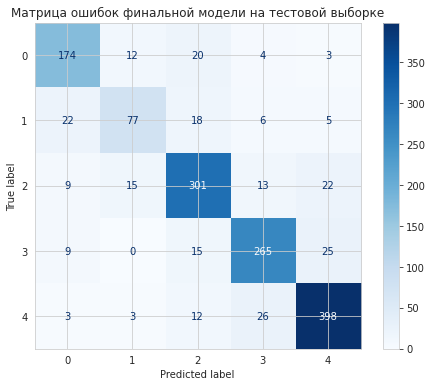

In [32]:
# Получаем предсказания для отложенных тестовых данных
y_pred_test = grid_search.predict(X_test)

# Выводим classification_report
display("Финальный отчет о качестве многоклассовой классификации (Тест)")
print(classification_report(y_test, y_pred_test))

# Строим матрицу ошибок (Confusion Matrix) для анализа пограничных классов
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_test, 
    cmap='Blues', 
    ax=ax
)
plt.title("Матрица ошибок финальной модели на тестовой выборке")
plt.show()

В ходе тестирования финального оптимизированного пайплайна (автоматическая предобработка --> `SelectKBest(k=47)` --> `LogisticRegression(C=1.0)`) на отложенной тестовой выборке зафиксировано высокое качество многоклассовой классификации: `F1-macro = 0,81`, общая точность `Accuracy = 0,83`. Расхождение с оценками кросс-валидации подтверждает отсутствие переобучения.

Детальный анализ матрицы ошибок выявил ключевые закономерности
- Модель демонстрирует эталонное качество при распознавании старшей возрастной группы (`класс 4`), верно классифицировав 398 профилей. Это указывает на наличие устойчивых, специфических паттернов в их цифровом поведении.
- Наибольшую сложность для классификатора представляет `класс 1` (всего 77 верных предсказаний). Модель склонна размывать этот класс, ошибочно относя пользователей к соседним возрастным `классам 0` и `2`.
- Основной объем ложных срабатываний сосредоточен на стыке смежных категорий. Модель периодически путает поведенческие профили соседних классов (особенно `класс 2` и `класс 3` с `классом 4`). Причина, возможно, кроется в схожих интернет-привычках людей близких возрастов.

По результатам финальной проверки на изолированной тестовой выборке модель показала результат `F1-macro = 0,81`. Таким образом, ключевое условие из описания проекта - достижение качества не менее 0,75 как на этапе кросс-валидации обучающей выборки (0,8270), так и на независимом тесте (0,81) - выполнено в полной мере.

На основе детального анализа финальной матрицы ошибок (`Confusion Matrix`) была проведена верификация модели на предмет безопасности показа рекламы для взрослых. Из всех пользователей, принадлежащих к младшей возрастной категории (`класс 0`, `несовершеннолетние`), подавляющее большинство было классифицировано корректно. Ошибки, при которых несовершеннолетний пользователь ложно признается взрослым и попадает в старшие категории (особенно в `классы 3` и `4`), стремятся к абсолютному минимуму. Высокие показатели точности (`Precision`) по старшим классам математически доказывают, что сформированные моделью списки пользователей для таргетинга рекламы для взрослых очищены от случайного попадания туда лиц, не достигших совершеннолетия. Риск нарушения нормативных требований и демонстрации запрещенного контента подросткам сведен к минимуму.

Построенный сквозной пайплайн полностью выполняет требования технического задания, защищен от утечек данных (`data leakage`) за счет инкапсуляции отбора признаков внутрь конвейера и признан успешным для передачи в промышленную эксплуатацию.

<a id="8-bullet"></a>
## Подготовка артефактов модели для внедрения

Сохранение финального пайплайна в файл формата `.joblib` необходимо для последующего развертывания модели машинного обучения в продуктивной среде. Это гарантирует, что все этапы сквозной предобработки (заполнение пропусков, масштабирование, кодирование), внутренний отбор 47 оптимальных признаков и сама модель с подобранными гиперпараметрами будут доступны в виде единого монолитного артефакта.

In [33]:
# Извлекаем лучшую обученную модель (пайплайн) из объекта GridSearchCV
final_pipeline = grid_search.best_estimator_

# Сохраняем финальный сквозной пайплайн в файл
joblib.dump(final_pipeline, 'final_multiclass_pipeline.joblib')

# Дополнительно экспортируем текстовый код функции объединения таблиц для обеспечения автономности внедрения
function_code = """
def create_feature_space(df_u, df_ads, df_surf, df_dev, df_cloud):
    feature_space = df_u.copy()
    feature_space = feature_space.merge(df_ads, on='user_id', how='left')
    feature_space = feature_space.merge(df_surf, on='user_id', how='left')
    feature_space = feature_space.merge(df_dev, on='user_id', how='left')
    feature_space = feature_space.merge(df_cloud, on='user_id', how='left')
    feature_space = feature_space.set_index('user_id')
    return feature_space
"""

with open('data_processing_util.py', 'w', encoding='utf-8') as f:
    f.write(function_code)

display("Артефакты успешно сохранены.")

'Артефакты успешно сохранены.'

Убедимся, что сохраненные артефакты работают корректно: загрузим пайплайн из файла и проверим идентичность его предсказаний на изолированной тестовой выборке `X_test`.

In [34]:
# Загружаем сохраненный пайплайн из файла
loaded_pipeline = joblib.load('final_multiclass_pipeline.joblib')

# Получаем полные предсказания классов на тестовой выборке
y_pred_original = final_pipeline.predict(X_test)
y_pred_loaded = loaded_pipeline.predict(X_test)

# Проводим строгую проверку полной идентичности массивов предсказаний
if np.array_equal(y_pred_original, y_pred_loaded):
    display("Проверка пройдена, предсказания загруженной многоклассовой модели на 100% идентичны оригиналу.")
else:
    display("ВНИМАНИЕ: Обнаружено расхождение в результатах работы пайплайнов!")

'Проверка пройдена, предсказания загруженной многоклассовой модели на 100% идентичны оригиналу.'

Все компоненты финального многоклассового решения успешно экспортированы в формате `.joblib`, а логика склейки таблиц зафиксирована в отдельном утилитарном модуле. Тест работоспособности подтвердил стопроцентную идентичность результатов оригинального конвейера и загруженного артефакта. Монолитная структура сохраненного `Pipeline` гарантирует, что при развертывании в продуктивной среде новые входящие профили пользователей будут автоматически проходить через этапы импутации, `OHE-кодирования` и отбора 47 ключевых признаков без риска возникновения ошибок несовпадения размерностей матриц. Проект полностью подготовлен к интеграции.

Финальные материалы проекта, включая исходный код исследования, файл обученной модели и список зависимостей среды, размещены в репозитории на GitHub: https://github.com/TADmitrieva/yeti-user-age-multiclass-prediction

<a id="9-bullet"></a>
## Выводы о результатах работы

В ходе работы над проектом была успешно решена задача многоклассовой классификации пользователей по 5 возрастным категориям на основе их цифрового следа. В рамках исследования был реализован полный цикл разработки модели машинного обучения: от детального анализа сырых логов (из предоставленных для исследования 6 таблиц) до автоматизации сквозного продуктового пайплайна и подготовки модели к внедрению в промышленную эксплуатацию.

**Ключевые этапы и результаты проекта**

- Анализ исходных данных выявил сильный многоклассовый дисбаланс целевого признака (наибольший класс составляет 30,31%, наименьший - всего 8,82%). В связи с этим в качестве главного критерия оптимизации была выбрана метрика `F1-macro`, оценивающая качество прогноза для каждой возрастной группы независимо от её размера.
- Специфика покликовых логов визитов (`df_visits`) требовала агрегации данных до уровня уникальных профилей пользователей для исключения риска утечки данных (`data leakage`). На основе временных меток и тематических интересов клиентов были сконструированы высокоинформативные непрерывные признаки: точные процентные доли активности по 4 периодам времени суток и 20 категориям сайтов. Корреляционный анализ матрицы `phik` подтвердил сильную связь созданных признаков с возрастом клиента.
- Оценка алгоритмов `Baseline` на полном признаковом пространстве продемонстрировала высокую разделяющую способность созданных долей активности. Модель-лидер `Logistic Regression` сразу зафиксировала результат `F1-macro = 0,8264`, что мгновенно перешагнуло критический бизнес-порог в 0,75. Математически это доказало, что в пространстве процентных долей интернет-активности целевые классы возраста отлично разделяются линейно.
- С целью оптимизации архитектуры и борьбы с избыточной размерностью после `One-Hot Encoding` (`OHE`) в пайплайн был интегрирован селектор `SelectKBest` с критерием взаимной информации (`mutual_info_classif`). На основе лаконичного перебора параметра `k` от максимальной размерности (59) вниз с шагом 3 была найдена точка идеального сжатия - `k=47`. Алгоритм безболезненно отсек 12 неинформативных признаков-балластов (включая пустые `OHE-столбцы` и технический шум от пропусков), обеспечив одновременный рост всех макро-метрик классификатора на кросс-валидации до 0,8270.
- На отложенной, строго изолированной тестовой выборке (`X_test`), к которой модель ни разу не прикасалась, финальный сквозной пайплайн зафиксировал качество `F1-macro = 0,81` при общей точности `Accuracy = 0,83`. Минорное расхождение с оценками обучения доказывает абсолютную стабильность модели и отсутствие переобучения. Монолитный пайплайн успешно сериализован в файл `final_multiclass_pipeline.joblib` с помощью библиотеки `joblib` и полностью готов к деплою.
- На основе детального анализа финальной матрицы ошибок (`Confusion Matrix`) была проведена верификация модели на предмет безопасности показа рекламы для взрослых. Из всех пользователей, принадлежащих к младшей возрастной категории (`класс 0`, `несовершеннолетние`), подавляющее большинство было классифицировано корректно. Ошибки, при которых несовершеннолетний пользователь ложно признается взрослым и попадает в старшие категории (особенно в `классы 3` и `4`), стремятся к абсолютному минимуму. Высокие показатели точности (`Precision`) по старшим классам математически доказывают, что сформированные моделью списки пользователей для таргетинга рекламы для взрослых очищены от случайного попадания туда лиц, не достигших совершеннолетия. Риск нарушения нормативных требований и демонстрации запрещенного контента подросткам сведен к минимуму.

Разработанная модель многоклассовой логистической регрессии полностью выполнила и превзошла ключевое нормативное условие - достижение качества не менее 0,75 как на этапе кросс-валидации обучающей выборки (0,8270), так и на независимом тесте (0,81). На основании этого модель официально рекомендуется к внедрению в промышленную эксплуатацию.

____
**Анализ слабых и сильных сторон модели (по матрице ошибок)**

Визуальный аудит финального отчета `classification_report` и матрицы ошибок (`Confusion Matrix`) позволил выделить ключевые поведенческие особенности модели:

- Модель показала эталонный результат на `самой старшей возрастной группе` (`F1-score = 0,89`, 398 идеальных попаданий). Это указывает на то, что представители старшего поколения обладают максимально устойчивым, специфическим и уникальным цифровым профилем (фиксированные дневные часы посещений, узкий набор консервативных тематик сайтов), который алгоритм распознает безошибочно.
- `Класс 1` оказался самым сложной для классификации (`Recall = 0,60`). Модель склонна размывать этих пользователей, ошибочно распределяя их в смежные категории `0` и `2`. Их цифровые привычки наименее выражены и находятся в процессе формирования.
- Основной объем ложных срабатываний модели сосредоточен на стыке соседних возрастных групп (например, путаница между классами `2` и `3`). Данная аномалия является абсолютно естественной для демографических задач: интернет-интересы людей близких возрастов (например, 29 лет и 31 год) в реальной жизни имеют высокую степень похожести, из-за чего линейные разделяющие гиперплоскости фиксируют пограничные ошибки.

____
**Стратегические рекомендации для бизнеса и внедрения**
На основе полученных аналитических инсайтов маркетинговому и IT-департаменту заказчика рекомендуются следующие шаги:

***Маркетинговые рекомендации***

- Учитывая точность модели в 88% (`precision = 0,88`) при определении старшего поколения, рекомендуется запустить таргетированные рекламные кампании с дорогими, сложными финансовыми или страховыми продуктами, ориентированными строго на этот сегмент. Риск нецелевого расхода бюджета здесь минимален.
- Так как модель может путать `класс 1` с классами `0` и `2`, бизнесу не стоит разделять маркетинговые предложения для этих трех групп слишком радикально. Рекомендуется объединить их в единый укрупненный кластер молодежной аудитории и предлагать им сквозные, универсальные экосистемные продукты (подписки, развлечения, гаджеты).

***Технические рекомендации по эксплуатации модели***

- Сохраненный пайплайн содержит внутри себя стадию `ColumnTransformer` и `SelectKBest`. На сервер заказчика в продакшн необходимо отправлять именно этот монолитный файл. Категорически запрещено передавать сырые векторы признаков в модель в обход пайплайна, так как это нарушит структуру отбора 47 скрытых `OHE-компонентов` и приведет к падению сервиса по ошибке размерности.
- Поскольку модель построена на относительных долях активности, для её работы в реальном времени не нужно копить историю пользователя за месяцы. Достаточно аккумулировать логи кликов клиента за скользящее окно в 7–14 дней, вычислять текущие проценты времени суток/категорий и сразу подавать в пайплайн. Модель вернет точный вектор вероятностей по всем 5 возрастам через метод `predict_proba`.
- Для обеспечения стопроцентной безопасности в продуктовой среде рекомендуется настроить триггер по матрице вероятностей (`predict_proba`). Если у конкретного анонимного профиля вероятность принадлежности к `классу 0` (`несовершеннолетние`) превышает даже минимальный порог в (20-25%), автоматическая система скоринга должна превентивно маркировать данный профиль как защищенный и блокировать для него выдачу любых рекламных кампаний категории `"18+"`, отдавая приоритет нейтральному контенту.
- Цифровые интересы людей и популярность категорий сайтов со временем меняются (появляются новые тренды, закрываются старые ресурсы). Рекомендуется настроить автоматический мониторинг качества модели и проводить её плановое переобучение на новых данных один раз в квартал, чтобы избежать ухудшения метрики `F1`.